In [1]:
import pandas as pd
import numpy as np
import random
from google.colab import drive

# Step 0: Install required packages
!pip install networkx matplotlib numpy pandas scikit-learn

# Step 1: Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# ---------------------------
# Step 1: Load dataset
# ---------------------------
df = pd.read_csv("/content/drive/MyDrive/Dataset/maternal.csv")







In [ ]:
# Features and labels
X = df.drop(["ID","target"], axis=1)
y = df["target"]

# ---------------------------
# Step 2: Train/Test split
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Dataset size:", len(df))
print("Train size:", len(X_train))
print("Test size:", len(X_test))

#

Dataset size: 1014
Train size: 811
Test size: 203


In [ ]:
df.describe()


,ID,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,target
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,507.500000,29.871795,113.198225,76.460552,8.725986,98.665089,74.301775,0.867850
std,292.860888,13.474386,18.403913,13.885796,3.293532,1.371384,8.088702,0.807353
min,1.000000,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000,0.000000
25%,254.250000,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000,0.000000
50%,507.500000,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000,1.000000
75%,760.750000,39.000000,120.000000,90.000000,8.000000,98.000000,80.000000,2.000000
max,1014.000000,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000,2.000000


In [ ]:
X.columns

Index(['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate'], dtype='object')

In [ ]:
#---------------------------
# Step 3: Direct ML (for feature importance)
# ---------------------------
rf_direct = RandomForestClassifier(random_state=42)
rf_direct.fit(X_train, y_train)
y_pred_direct = rf_direct.predict(X_test)

print("\n=== Direct ML Metrics ===")
print("Accuracy:", accuracy_score(y_test, y_pred_direct))
print("Precision:", precision_score(y_test, y_pred_direct, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_direct, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_direct, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_direct))




=== Direct ML Metrics ===
Accuracy: 0.8522167487684729
Precision: 0.851993927473478
Recall: 0.8522167487684729
F1 Score: 0.8514397128335885
Confusion Matrix:
 [[66 14  1]
 [ 8 54  5]
 [ 2  0 53]]


In [ ]:
display(df['target'].value_counts())

,count
target,
0,406
1,336
2,272


In [ ]:
# Compute feature importance
feature_importances = pd.Series(rf_direct.feature_importances_, index=X_train.columns)
filter_attributes = feature_importances.sort_values(ascending=False).index.tolist()
print("\nFilter attributes by importance:", filter_attributes)

#


Filter attributes by importance: ['BS', 'SystolicBP', 'Age', 'DiastolicBP', 'HeartRate', 'BodyTemp']


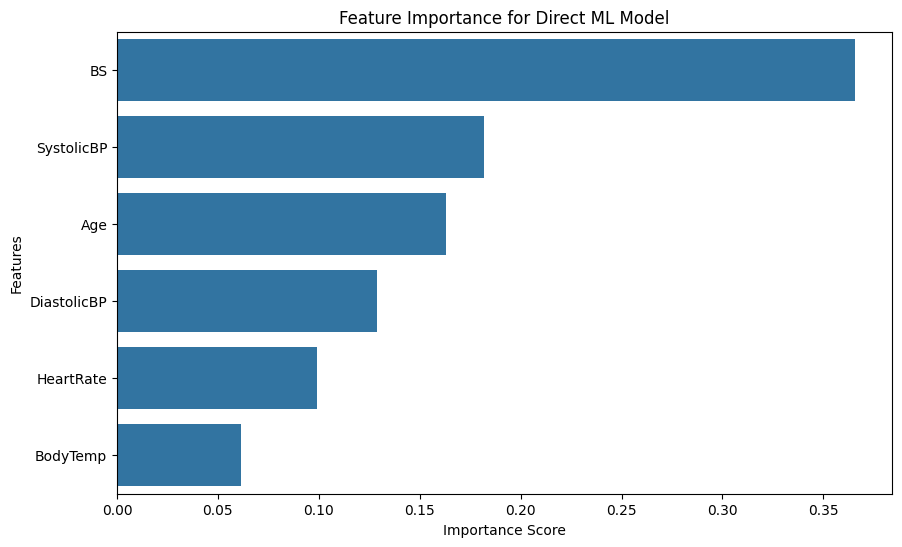

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort feature importances for visualization
feature_importances = feature_importances.sort_values(ascending=False)

# Visualize feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances.values, y=feature_importances.index)
plt.title("Feature Importance for Direct ML Model")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# ---------------------------
# Step 1: Load dataset
# ---------------------------
df = pd.read_csv("/content/drive/MyDrive/Dataset/maternal.csv")


# Features and labels
X = df.drop(["target"], axis=1)
y = df["target"]

# ---------------------------
# Step 2: Train/Test split
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Dataset size:", len(df))
print("Train size:", len(X_train))
print("Test size:", len(X_test))

# ---------------------------
# Step 3: Direct ML (Initial run for feature importance - for reference)
# ---------------------------
rf_direct_initial = RandomForestClassifier(random_state=42)
rf_direct_initial.fit(X_train, y_train)
importances = rf_direct_initial.feature_importances_
feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)
# top_features = feat_imp.head(10).index.tolist()  # Keep top 10 features

# Use only the features specified by the user
top_features = [ 'BS','SystolicBP','Age']
print("Selected filter attributes:", top_features)


# Filter X_train and X_test to keep only top features
X_train_filtered = X_train[top_features]
X_test_filtered = X_test[top_features]


# ---------------------------
# Step 4: Direct ML (with filtered features)
# ---------------------------
rf_direct = RandomForestClassifier(n_estimators=5, random_state=42)
rf_direct.fit(X_train_filtered, y_train)
y_pred_direct = rf_direct.predict(X_test_filtered)

print("\n=== Direct ML Metrics (Filtered Features) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_direct))
print("Precision:", precision_score(y_test, y_pred_direct, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred_direct, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_direct, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_direct))

# ---------------------------
# Step 5: Prepare data for Reeb graph (using filtered features)
# ---------------------------
train_df = X_train_filtered.copy()
train_df["Class"] = y_train


Dataset size: 1014
Train size: 811
Test size: 203
Selected filter attributes: ['BS', 'SystolicBP', 'Age']

=== Direct ML Metrics (Filtered Features) ===
Accuracy: 0.8029556650246306
Precision: 0.8039226318124842
Recall: 0.8029556650246306
F1 Score: 0.803335989568241
Confusion Matrix:
 [[65 15  1]
 [11 50  6]
 [ 3  4 48]]


In [ ]:
#  (multi-D clustering, medoids, SMOTE, k-NN mapping, hybrid RF)
# Requires: numpy, pandas, sklearn, imblearn
# Example usage at bottom.

import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from imblearn.over_sampling import SMOTE
import warnings

warnings.filterwarnings("ignore")


def choose_best_k(data_2d, k_min=2, k_max=6, random_state=42):
    """Choose best k using silhouette score. Returns (best_k, labels, centers) or (None, None, None)."""
    best_k = None
    best_score = -1
    best_labels = None
    best_centers = None
    n_samples = data_2d.shape[0]
    if n_samples < k_min:
        return None, None, None
    k_max = min(k_max, n_samples)
    for k in range(k_min, k_max + 1):
        try:
            km = KMeans(n_clusters=k, random_state=random_state, n_init=10)
            labels = km.fit_predict(data_2d)
            if len(np.unique(labels)) < 2:
                continue
            score = silhouette_score(data_2d, labels)
            #print(f"K={k}, silhouette score={score}")
            if score > best_score:
                best_score = score
                best_k = k
                best_labels = labels
                best_centers = km.cluster_centers_
        except Exception:
            continue
    return best_k, best_labels, best_centers


def medoid_of_group(X_group):
    """
    Return medoid index and medoid vector for a DataFrame/2D-array X_group.
    Medoid = row with minimum sum of distances to others (or to centroid if faster).
    """
    arr = np.asarray(X_group)
    if len(arr) == 1:
        return 0, arr[0]
    # compute centroid then pick sample closest to centroid (fast, robust)
    centroid = np.mean(arr, axis=0)
    dists = np.linalg.norm(arr - centroid, axis=1)
    idx = int(np.argmin(dists))
    return idx, arr[idx]


def merge_small_clusters(labels, cluster_centers, min_samples, data_2d):
    """
    Merge clusters that have <min_samples with nearest larger cluster.
    Returns new labels (np.array) and possibly updated centers (not re-computed here).
    """
    labels = labels.copy()
    unique = np.unique(labels)
    # get cluster sizes
    sizes = {u: np.sum(labels == u) for u in unique}
    # If all clusters are >= min_samples, nothing to do
    small = [u for u, s in sizes.items() if s < min_samples]
    if not small:
        return labels

    # compute centers if not given:
    centers = np.asarray(cluster_centers)
    for s in small:
        small_idx = np.where(labels == s)[0]
        if len(small_idx) == 0:
            continue
        # find closest other cluster center
        d_to_centers = np.linalg.norm(centers - centers[s], axis=1)
        # exclude itself
        d_to_centers[s] = np.inf
        nearest = int(np.argmin(d_to_centers))
        # reassign labels of small cluster to 'nearest'
        labels[labels == s] = nearest

    # optionally compress labels so they are contiguous (not necessary)
    unique_after = np.unique(labels)
    mapping = {old: new for new, old in enumerate(unique_after)}
    new_labels = np.array([mapping[l] for l in labels])
    return new_labels


def cluster_and_recurse(df, attrs, min_samples=10, max_bins=6, k_features=2, depth=0, max_depth=10, random_state=42):
    """
    Recursively cluster on top k_features (attributes) jointly, adaptively choose k using silhouette,
    merge small clusters, and preserve small clusters rather than discarding them (we return them as leaf groups).
    Returns a list of leaf DataFrames.
    """
    # termination conditions
    if depth >= max_depth or len(attrs) == 0 or len(df) < min_samples:
        return [df] if len(df) >= 1 else []

    # choose feature subset for clustering at this level
    use_attrs = attrs[:k_features] if len(attrs) >= k_features else attrs
    data_for_clustering = df[use_attrs].values

    # standardize before clustering (important for mixed-scale features)
    scaler = StandardScaler()
    try:
        data_scaled = scaler.fit_transform(data_for_clustering)
    except Exception:
        data_scaled = data_for_clustering.copy()

    # If we have more than 2 dims, reduce to 2D for silhouette + KMeans stability
    if data_scaled.shape[1] > 2:
        pca = PCA(n_components=2, random_state=random_state)
        try:
            proj = pca.fit_transform(data_scaled)
        except Exception:
            proj = data_scaled[:, :2]
    else:
        proj = data_scaled

    # adaptive k
    best_k, best_labels, centers = choose_best_k(proj, k_min=2, k_max=max_bins, random_state=random_state)
    print("Best_k, best labels, centers",best_k, best_labels, centers)
    if best_k is None:
        # cannot cluster meaningfully -> treat current df as leaf
        return [df]

    # merge small clusters
    labels_merged = merge_small_clusters(best_labels, centers, min_samples, proj)
    print("labels merged",labels_merged)
    leaf_nodes = []
    for label in np.unique(labels_merged):
        sub_df = df[labels_merged == label]
        if len(sub_df) >= min_samples:
            # Recurse on remaining attributes (drop the used attrs to encourage variety)
            next_attrs = attrs.copy()
            # Option: rotate attrs so we do not repeatedly split on same attributes
            # Here we simply use attrs[1:] to keep behavior similar to previous approach but with multi-D
            if len(next_attrs) > 1:
                next_attrs = next_attrs[1:]
            leaf_nodes.extend(cluster_and_recurse(sub_df, next_attrs, min_samples, max_bins,
                                                  k_features=k_features, depth=depth+1, max_depth=max_depth,
                                                  random_state=random_state))
        else:
            # preserve minority cluster as a leaf (do not discard)
            leaf_nodes.append(sub_df)

    return leaf_nodes


def apply_smote_inside_group(group_df, feature_cols, class_col="Class", smote_min_size=6, random_state=42):
    """
    Apply SMOTE only if group has more than one class and size >= smote_min_size.
    Returns new group dataframe (possibly unchanged on failure).
    """
    if len(group_df) < smote_min_size:
        return group_df
    y = group_df[class_col]
    if len(y.unique()) < 2:
        return group_df
    X = group_df[feature_cols]
    try:
        sm = SMOTE(random_state=random_state, k_neighbors=min(5, len(group_df)-1))
        X_res, y_res = sm.fit_resample(X.values, y.values)
        df_new = pd.DataFrame(X_res, columns=feature_cols)
        df_new[class_col] = y_res
        return df_new
    except Exception:
        return group_df


def create_reeb_nodes_from_leaf_groups(leaf_groups, feature_cols, class_col="Class", apply_smote_flag=True):
    """
    For each leaf group:
     - optionally apply SMOTE,
     - compute medoid prototype,
     - compute soft class distribution,
     - store node info
    Returns: reeb_df (DataFrame of prototypes + hard label), node_list (list of dicts with metadata)
    """
    nodes = []
    for grp in leaf_groups:
        if len(grp) == 0:
            continue
        # ensure we are working on a fresh copy
        group = grp.copy().reset_index(drop=True)
        if apply_smote_flag:
            group = apply_smote_inside_group(group, feature_cols, class_col=class_col)
            print("smote group",group)
        # medoid selection
        medoid_idx, medoid_vec = medoid_of_group(group[feature_cols].values)
        print(" medoid_idx, medoid_vec", medoid_idx, medoid_vec)
        medoid_series = group[feature_cols].iloc[medoid_idx].values

        # soft label distribution
        dist = group[class_col].value_counts(normalize=True).to_dict()
        # majority class
        majority = max(dist.items(), key=lambda x: x[1])[0]

        node = {
            "medoid_features": medoid_series,
            "majority_class": majority,
            "class_distribution": dist,
            "group_size": len(group)
        }
        print(node.values())
        nodes.append(node)

    # Build reeb_df for hard-label training if nodes exist
    if len(nodes) == 0:
        return None, []

    reeb_df = pd.DataFrame([list(n["medoid_features"]) + [n["majority_class"]] for n in nodes],
                           columns=list(feature_cols) + [class_col])
    return reeb_df, nodes


def compute_node_distances(X_df, nodes, feature_cols):
    """
    Compute distances from each sample in X_df to every node medoid.
    Returns a 2D numpy array (n_samples x n_nodes).
    """
    if nodes is None or len(nodes) == 0:
        return np.zeros((len(X_df), 0))
    node_feats = np.vstack([n["medoid_features"] for n in nodes])
    print("compute node distance",node_feats)
    X_arr = X_df[feature_cols].values
    # pairwise distances (euclidean)
    dists = np.linalg.norm(X_arr[:, None, :] - node_feats[None, :, :], axis=2)
    return dists


def map_test_samples_to_nodes(X_test_df, nodes, feature_cols, k_nodes=3):
    """
    Map test samples to k nearest reeb nodes and produce predicted class using
    distance-weighted vote across node class distributions.
    Returns a list/array of predicted class labels.
    """
    if nodes is None or len(nodes) == 0:
        # no nodes => cannot map; return None so caller can fallback
        return None

    dists = compute_node_distances(X_test_df, nodes, feature_cols)  # shape (n_samples, n_nodes)
    print("distance",dists)
    n_nodes = dists.shape[1]
    # For each test sample:
    preds = []
    for i in range(dists.shape[0]):
        # indices of nearest nodes
        k = min(k_nodes, n_nodes)
        nearest_idx = np.argsort(dists[i])[:k]
        # Weighted vote using inverse distance (add small epsilon)
        eps = 1e-8
        weights = 1.0 / (dists[i][nearest_idx] + eps)
        # aggregate class distributions
        agg = {}
        for idx, w in zip(nearest_idx, weights):
            node = nodes[idx]
            for cls, prob in node["class_distribution"].items():
                agg[cls] = agg.get(cls, 0.0) + w * prob
                print("insode mapping test samples",agg[cls])
        # choose class with max aggregate score
        if len(agg) == 0:
            preds.append(nodes[nearest_idx[0]]["majority_class"])
        else:
            pred = max(agg.items(), key=lambda x: x[1])[0]
            preds.append(pred)
    return np.array(preds)


def train_hybrid_rf(X_train_df, y_train_series, nodes, feature_cols, n_estimators=200, random_state=42):
    """
    Train RandomForest on raw features augmented with distances to node medoids.
    Returns trained RF and the augmented training DataFrame used.
    """
    # compute distances features
    dists_train = compute_node_distances(X_train_df, nodes, feature_cols)  # shape (n_samples, n_nodes)
    print("dists_train inside train_hybrid",dists_train)
    # create column names for distances
    dist_cols = [f"dist_node_{i}" for i in range(dists_train.shape[1])]
    df_aug = X_train_df.copy().reset_index(drop=True)
    for i, col in enumerate(dist_cols):
        df_aug[col] = dists_train[:, i]

    # RF with class_weight balanced to handle class imbalance
    rf = RandomForestClassifier(n_estimators=n_estimators, random_state=random_state, class_weight='balanced')
    rf.fit(df_aug.values, y_train_series.values)
    return rf, df_aug, dist_cols


def evaluate_predictions(y_true, y_pred, average='weighted'):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average=average, zero_division=0)
    rec = recall_score(y_true, y_pred, average=average)
    f1 = f1_score(y_true, y_pred, average=average)
    cm = confusion_matrix(y_true, y_pred)
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "confusion_matrix": cm}


# -------------------------
# Example pipeline orchestration
# -------------------------
def reeb_pipeline(X_train_filtered, y_train, X_test_filtered, y_test,
                  top_features=None,
                  min_samples=10,
                  max_bins=6,
                  k_features=2,
                  k_map_nodes=3,
                  apply_smote_flag=True,
                  max_depth=10,
                  random_state=42):
    """
    Run the whole improved Reeb pipeline and evaluate.
    Returns a dict with models, nodes, predictions and metrics.
    """
    if top_features is None:
        top_features = list(X_train_filtered.columns)

    # prepare train_df with class column for clustering
    train_df = X_train_filtered.copy().reset_index(drop=True)
    train_df["Class"] = y_train.reset_index(drop=True)

    # Step A: hierarchical clustering to obtain leaf groups
    print("Generating leaf groups with multi-D adaptive clustering...")
    leaf_groups = cluster_and_recurse(train_df, top_features.copy(), min_samples=min_samples,
                                      max_bins=max_bins, k_features=k_features,
                                      max_depth=max_depth, random_state=random_state)
    print(f"Number of leaf groups obtained: {len(leaf_groups)}")

    # Step B: create reeb nodes from leaf groups (medoid, soft labels, optional SMOTE)
    print("Creating Reeb nodes (medoids + soft labels + optional SMOTE inside groups)...")
    reeb_df, nodes = create_reeb_nodes_from_leaf_groups(leaf_groups, feature_cols=top_features,
                                                        class_col="Class", apply_smote_flag=apply_smote_flag)
    print("reeb_df:",reeb_df)
    print("nodes:",nodes)
    if nodes is None or len(nodes) == 0:
        print("Warning: no Reeb nodes could be created. Falling back to standard RF on raw data.")
        # fallback RF on raw features
        rf_fallback = RandomForestClassifier(n_estimators=20, random_state=random_state, class_weight='balanced')
        rf_fallback.fit(X_train_filtered.values, y_train.values)
        y_pred_fb = rf_fallback.predict(X_test_filtered.values)
        metrics_fb = evaluate_predictions(y_test, y_pred_fb)
        return {
            "nodes": [],
            "reeb_df": None,
            "rf_model": rf_fallback,
            "y_pred": y_pred_fb,
            "metrics": metrics_fb
        }

    print(f"Created {len(nodes)} Reeb nodes. Sample node sizes: {[n['group_size'] for n in nodes[:10]]}")

    # Step C: Train hybrid RF on raw + distances to nodes
    print("Training hybrid RandomForest on raw features augmented with distances to node medoids...")
    rf_hybrid, df_aug_train, dist_cols = train_hybrid_rf(X_train_filtered, y_train, nodes, top_features,
                                                         n_estimators=2, random_state=random_state)

    # Step D: Map test samples using k-NN mapping to nodes (distance-weighted) -> predictions_map
    print(f"Mapping test samples to {k_map_nodes} nearest nodes and producing node-based predictions...")
    preds_node_map = map_test_samples_to_nodes(X_test_filtered, nodes, top_features, k_nodes=k_map_nodes)

    # Step E: Also predict using hybrid RF by augmenting test with distance features
    print("Augmenting test features with distances to nodes for hybrid RF prediction...")
    dists_test = compute_node_distances(X_test_filtered, nodes, top_features)
    print("dists_test",dists_test)
    df_aug_test = X_test_filtered.copy().reset_index(drop=True)
    for i, col in enumerate([f"dist_node_{i}" for i in range(dists_test.shape[1])]):
        df_aug_test[col] = dists_test[:, i]

    y_pred_hybrid = rf_hybrid.predict(df_aug_test.values)
    print("augmented training", df_aug_train)
    print("augmented test", df_aug_test)
    # Evaluate both node-mapping and hybrid RF
    print("Evaluating node-mapping predictions (distance-weighted k-NN to nodes)...")
    metrics_nodes = None
    if preds_node_map is not None:
        metrics_nodes = evaluate_predictions(y_test, preds_node_map)

    print("Evaluating hybrid RF predictions (raw features + node-distances)...")
    metrics_hybrid = evaluate_predictions(y_test, y_pred_hybrid)

    # Aggregate results
    results = {
        "nodes": nodes,
        "reeb_df": reeb_df,
        "rf_hybrid": rf_hybrid,
        "y_pred_node_map": preds_node_map,
        "metrics_node_map": metrics_nodes,
        "y_pred_hybrid": y_pred_hybrid,
        "metrics_hybrid": metrics_hybrid,
        "df_aug_train": df_aug_train,
        "df_aug_test": df_aug_test
    }

    print("Done.")
    return results


# -------------------------
# Minimal example of how to call (uncomment & adapt to your variable names)
# -------------------------
# Example usage (assuming you have X_train_filtered, y_train, X_test_filtered, y_test defined):
#
results = reeb_pipeline(
     X_train_filtered=X_train_filtered,
     y_train=y_train,
     X_test_filtered=X_test_filtered,
     y_test=y_test,
     top_features=top_features,   # list of feature column names
     min_samples=8,
     max_bins=6,
     k_features=3,
     k_map_nodes=3,
     apply_smote_flag=True,
     max_depth=8,
     random_state=42
 )

print("Hybrid RF metrics:", results["metrics_hybrid"])
if results["metrics_node_map"] is not None:
     print("Node-mapping metrics:", results["metrics_node_map"])
#
# You can inspect results["nodes"] to see medoid prototypes and class distributions.

Generating leaf groups with multi-D adaptive clustering...
Best_k, best labels, centers 5 [3 3 0 1 0 4 1 0 2 3 0 0 3 3 1 3 3 3 3 4 3 3 3 3 3 0 0 3 3 0 1 3 3 3 2 2 0
 0 1 1 2 3 3 1 0 0 3 3 3 4 0 4 3 3 3 0 4 0 0 3 1 3 4 3 0 3 3 3 3 3 4 3 3 3
 2 1 0 0 0 1 4 3 4 3 1 3 3 0 1 3 3 3 0 0 3 4 3 1 3 0 3 3 3 3 2 1 0 0 3 3 3
 2 3 0 0 3 3 3 3 0 3 0 1 3 1 1 3 3 3 0 3 4 3 3 1 3 3 4 1 0 1 3 0 3 3 0 4 1
 0 3 3 3 0 1 3 0 0 0 0 0 4 3 3 3 4 3 3 0 0 3 0 0 3 1 3 0 1 3 3 3 3 0 0 3 0
 1 0 4 1 3 3 3 0 3 1 3 3 3 3 0 0 4 0 0 3 1 1 3 3 1 3 3 3 3 3 3 3 3 1 3 1 1
 4 1 0 4 0 0 3 0 2 1 4 1 0 0 0 0 4 3 1 3 3 3 0 1 3 3 3 1 1 1 4 0 2 0 1 2 3
 0 3 0 0 1 0 0 0 4 1 3 3 3 1 0 3 3 0 1 4 0 3 0 2 4 0 0 2 3 1 3 0 3 4 3 3 1
 3 0 0 0 0 3 0 0 1 2 0 1 3 1 3 0 0 3 0 0 0 3 3 0 3 4 1 3 0 0 3 4 3 0 0 0 1
 1 3 0 4 3 0 1 3 4 0 2 4 3 0 1 4 1 4 2 4 3 0 0 1 3 3 0 0 3 0 3 2 4 0 3 0 3
 4 0 3 0 0 3 2 0 1 3 2 3 1 0 4 2 3 1 3 0 1 0 3 1 3 3 3 3 1 3 0 4 1 3 0 2 0
 3 3 3 0 0 0 4 0 0 0 4 0 0 2 0 0 4 1 4 3 4 3 3 4 1 0 3 3 3 3 3 3 0 4 2 0 1
 1 3 1 3 1

In [ ]:
!pip install imblearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.0/240.0 kB 8.5 MB/s eta 0:00:00


Where limitations show

Very high-dimensional datasets (e.g., text, images)

PCA down to 2D loses too much structure; deep embeddings may be needed before your pipeline.

Tiny datasets

SMOTE requires at least a few minority samples; oversampling may fail if groups are very small.

Perfectly balanced, linearly separable datasets

Your method may be “over-engineered” compared to simpler classifiers (like logistic regression or SVM).

Streaming or non-stationary data

Recursive binning + static medoid prototypes assume stationarity; not directly suited for evolving data without modification.

In [ ]:
# ---------------------------
# Step 6: Group data by target and compute centroid/medoid for each group
# ---------------------------
print("\n=== Grouping by target and computing centroids/medoids ===")

# Group by 'target'
grouped_by_target = df.groupby("target")

centroids = grouped_by_target[top_features].mean()
print("\nCentroids by target:\n", centroids)

medoids = {}
for name, group in grouped_by_target:
    # Compute medoid for each group using the helper function
    idx, medoid_vec = medoid_of_group(group[top_features])
    medoids[name] = pd.Series(medoid_vec, index=top_features)

medoids_df = pd.DataFrame(medoids).T
print("\nMedoids by target:\n", medoids_df)

# ---------------------------
# Step 7: Create augmented features (distances to centroids and medoids)
# ---------------------------
print("\n=== Creating augmented features ===")

def add_distance_features(X_df, centroids_df, medoids_df, feature_cols):
    X_aug = X_df.copy()
    for target_class in centroids_df.index:
        centroid = centroids_df.loc[target_class, feature_cols].values
        medoid = medoids_df.loc[target_class, feature_cols].values

        # Calculate Euclidean distance to centroid
        dist_to_centroid = np.linalg.norm(X_df[feature_cols].values - centroid, axis=1)
        X_aug[f'dist_to_centroid_{target_class}'] = dist_to_centroid

        # Calculate Euclidean distance to medoid
        dist_to_medoid = np.linalg.norm(X_df[feature_cols].values - medoid, axis=1)
        X_aug[f'dist_to_medoid_{target_class}'] = dist_to_medoid
    return X_aug

X_train_augmented = add_distance_features(X_train_filtered, centroids, medoids_df, top_features)
X_test_augmented = add_distance_features(X_test_filtered, centroids, medoids_df, top_features)

print("\nAugmented training data head:\n", X_train_augmented.head())
print("\nAugmented test data head:\n", X_test_augmented.head())


# ---------------------------
# Step 8: Train and test RandomForest with augmented features
# ---------------------------
print("\n=== Training and testing RandomForest with augmented features ===")

rf_augmented = RandomForestClassifier(n_estimators=100, random_state=42)
rf_augmented.fit(X_train_augmented, y_train)
y_pred_augmented = rf_augmented.predict(X_test_augmented)

print("\n=== RandomForest Metrics (Augmented Features) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_augmented))
print("Precision:", precision_score(y_test, y_pred_augmented, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred_augmented, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_augmented, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_augmented))


=== Grouping by target and computing centroids/medoids ===

Centroids by target:
                BS  SystolicBP        Age
target                                  
0        7.220271  105.866995  26.869458
1        7.795744  113.154762  28.363095
2       12.122610  124.194853  36.216912

Medoids by target:
       BS  SystolicBP   Age
0   7.01       110.0  25.0
1   7.80       115.0  28.0
2  11.00       120.0  37.0

=== Creating augmented features ===

Augmented training data head:
       BS  SystolicBP  Age  dist_to_centroid_0  dist_to_medoid_0  \
558  6.1         120   31           14.766794         11.697354   
911  7.8         120   23           14.664604         10.228592   
179  7.5          90   13           21.076092         23.328954   
512  7.5         120   42           20.706361         19.729169   
692  6.0          85   26           20.920719         25.040369   

     dist_to_centroid_1  dist_to_medoid_1  dist_to_centroid_2  \
558            7.529017          6.073714     

**Structural Boosting for Random Forest Classification**

In [ ]:
# ---------------------------
# Step 7 (Modified): Create augmented features (distances only to medoids)
# ---------------------------
print("\n=== Creating augmented features (Medoid distances only) ===")

def add_medoid_distance_features(X_df, medoids_df, feature_cols):
    X_aug = X_df.copy()
    for target_class in medoids_df.index:
        medoid = medoids_df.loc[target_class, feature_cols].values

        # Calculate Euclidean distance to medoid
        dist_to_medoid = np.linalg.norm(X_df[feature_cols].values - medoid, axis=1)
        X_aug[f'dist_to_medoid_{target_class}'] = dist_to_medoid
    return X_aug

X_train_augmented_medoid = add_medoid_distance_features(X_train_filtered, medoids_df, top_features)
X_test_augmented_medoid = add_medoid_distance_features(X_test_filtered, medoids_df, top_features)

print("\nAugmented training data head (Medoid distances only):\n", X_train_augmented_medoid.head())
print("\nAugmented test data head (Medoid distances only):\n", X_test_augmented_medoid.head())


# ---------------------------
# Step 8 (Modified): Train and test RandomForest with medoid-augmented features
# ---------------------------
print("\n=== Training and testing RandomForest with medoid-augmented features ===")

rf_augmented_medoid = RandomForestClassifier(n_estimators=100, random_state=42)
rf_augmented_medoid.fit(X_train_augmented_medoid, y_train)
y_pred_augmented_medoid = rf_augmented_medoid.predict(X_test_augmented_medoid)

print("\n=== RandomForest Metrics (Medoid-Augmented Features) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_augmented_medoid))
print("Precision:", precision_score(y_test, y_pred_augmented_medoid, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred_augmented_medoid, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_augmented_medoid, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_augmented_medoid))


=== Creating augmented features (Medoid distances only) ===

Augmented training data head (Medoid distances only):
       BS  SystolicBP  Age  dist_to_medoid_0  dist_to_medoid_1  \
558  6.1         120   31         11.697354          6.073714   
911  7.8         120   23         10.228592          7.071068   
179  7.5          90   13         23.328954         29.156303   
512  7.5         120   42         19.729169         14.869095   
692  6.0          85   26         25.040369         30.120425   

     dist_to_medoid_2  
558          7.746612  
911         14.361058  
179         38.577843  
512          6.103278  
692         37.027017  

Augmented test data head (Medoid distances only):
       BS  SystolicBP  Age  dist_to_medoid_0  dist_to_medoid_1  \
693  7.7         130   29         20.407746         15.033629   
725  6.9          90   17         21.540940         27.327825   
642  7.5         120   50         26.930282         22.563023   
799  7.9         120   23         10

In [ ]:
# ---------------------------
# Step 7 (Modified): Create augmented features (distances only to centroids)
# ---------------------------
print("\n=== Creating augmented features (Centroid distances only) ===")

def add_centroid_distance_features(X_df, centroids_df, feature_cols):
    X_aug = X_df.copy()
    for target_class in centroids_df.index:
        centroid = centroids_df.loc[target_class, feature_cols].values

        # Calculate Euclidean distance to centroid
        dist_to_centroid = np.linalg.norm(X_df[feature_cols].values - centroid, axis=1)
        X_aug[f'dist_to_centroid_{target_class}'] = dist_to_centroid
    return X_aug

X_train_augmented_centroid = add_centroid_distance_features(X_train_filtered, centroids, top_features)
X_test_augmented_centroid = add_centroid_distance_features(X_test_filtered, centroids, top_features)

print("\nAugmented training data head (Centroid distances only):\n", X_train_augmented_centroid.head())
print("\nAugmented test data head (Centroid distances only):\n", X_test_augmented_centroid.head())


# ---------------------------
# Step 8 (Modified): Train and test RandomForest with centroid-augmented features
# ---------------------------
print("\n=== Training and testing RandomForest with centroid-augmented features ===")

rf_augmented_centroid = RandomForestClassifier(n_estimators=100, random_state=42)
rf_augmented_centroid.fit(X_train_augmented_centroid, y_train)
y_pred_augmented_centroid = rf_augmented_centroid.predict(X_test_augmented_centroid)

print("\n=== RandomForest Metrics (Centroid-Augmented Features) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_augmented_centroid))
print("Precision:", precision_score(y_test, y_pred_augmented_centroid, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred_augmented_centroid, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_augmented_centroid, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_augmented_centroid))


=== Creating augmented features (Centroid distances only) ===

Augmented training data head (Centroid distances only):
       BS  SystolicBP  Age  dist_to_centroid_0  dist_to_centroid_1  \
558  6.1         120   31           14.766794            7.529017   
911  7.8         120   23           14.664604            8.695981   
179  7.5          90   13           21.076092           27.789479   
512  7.5         120   42           20.706361           15.261387   
692  6.0          85   26           20.920719           28.310767   

     dist_to_centroid_2  
558            9.004710  
911           14.524755  
179           41.589440  
512            8.509373  
692           40.964718  

Augmented test data head (Centroid distances only):
       BS  SystolicBP  Age  dist_to_centroid_0  dist_to_centroid_1  \
693  7.7         130   29           24.231617           16.857546   
725  6.9          90   17           18.688775           25.808241   
642  7.5         120   50           27.107970  

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# ---------------------------
# Step 28: Train and Test AdaBoost Classifier
# ---------------------------
print("\n=== Training and testing AdaBoost Classifier (Original Features) ===")

# Instantiate and train the AdaBoost Classifier
# Using default parameters for now
adaboost_clf = AdaBoostClassifier(random_state=42)
adaboost_clf.fit(X_train_filtered, y_train)

# Predict on the test data
y_pred_adaboost = adaboost_clf.predict(X_test_filtered)

# Evaluate the AdaBoost Classifier
print("\n=== AdaBoost Classifier Metrics (Original Features) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_adaboost))
print("Precision:", precision_score(y_test, y_pred_adaboost, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred_adaboost, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_adaboost, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_adaboost))


=== Training and testing AdaBoost Classifier (Original Features) ===

=== AdaBoost Classifier Metrics (Original Features) ===
Accuracy: 0.6551724137931034
Precision: 0.6426964074742165
Recall: 0.6551724137931034
F1 Score: 0.6466308257259049
Confusion Matrix:
 [[56 25  0]
 [31 27  9]
 [ 2  3 50]]


In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# ---------------------------
# Step 29: Train and Test AdaBoost Classifier (Medoid-Augmented Features)
# ---------------------------
print("\n=== Training and testing AdaBoost Classifier (Medoid-Augmented Features) ===")

# Instantiate and train the AdaBoost Classifier
# Using default parameters for now
adaboost_augmented_medoid = AdaBoostClassifier(random_state=42)
adaboost_augmented_medoid.fit(X_train_augmented_medoid, y_train)

# Predict on the test data
y_pred_adaboost_augmented_medoid = adaboost_augmented_medoid.predict(X_test_augmented_medoid)

# Evaluate the AdaBoost Classifier
print("\n=== AdaBoost Classifier Metrics (Medoid-Augmented Features) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_adaboost_augmented_medoid))
print("Precision:", precision_score(y_test, y_pred_adaboost_augmented_medoid, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred_adaboost_augmented_medoid, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_adaboost_augmented_medoid, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_adaboost_augmented_medoid))


=== Training and testing AdaBoost Classifier (Medoid-Augmented Features) ===

=== AdaBoost Classifier Metrics (Medoid-Augmented Features) ===
Accuracy: 0.5812807881773399
Precision: 0.5684477041341812
Recall: 0.5812807881773399
F1 Score: 0.5724536725509592
Confusion Matrix:
 [[51 30  0]
 [38 20  9]
 [ 4  4 47]]



=== Visualizing X_train_augmented_medoid in 3D using PCA ===


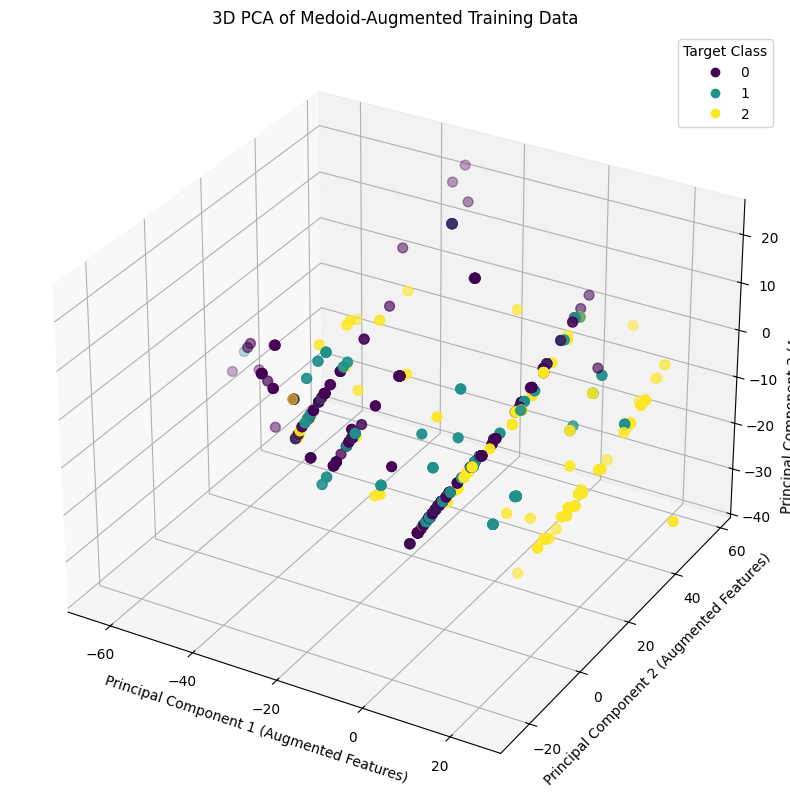

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA
import numpy as np

# ---------------------------
# Step 15: Visualize X_train_augmented_medoid in 3D using PCA
# ---------------------------
print("\n=== Visualizing X_train_augmented_medoid in 3D using PCA ===")

# Use PCA to reduce the augmented training data to 3 dimensions
pca_augmented_3d = PCA(n_components=3, random_state=42)
X_pca_augmented_train_3d = pca_augmented_3d.fit_transform(X_train_augmented_medoid)

# Create a DataFrame for easier plotting
pca_augmented_train_df_3d = pd.DataFrame(data=X_pca_augmented_train_3d, columns=['PCA1', 'PCA2', 'PCA3'])
pca_augmented_train_df_3d['target'] = y_train.reset_index(drop=True) # Reset index to align with PCA results


fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot data points, colored by target
scatter_aug_3d = ax.scatter(pca_augmented_train_df_3d['PCA1'],
                            pca_augmented_train_df_3d['PCA2'],
                            pca_augmented_train_df_3d['PCA3'],
                            c=pca_augmented_train_df_3d['target'],
                            cmap='viridis',
                            s=50)

ax.set_title('3D PCA of Medoid-Augmented Training Data')
ax.set_xlabel('Principal Component 1 (Augmented Features)')
ax.set_ylabel('Principal Component 2 (Augmented Features)')
ax.set_zlabel('Principal Component 3 (Augmented Features)')

# Create a legend mapping colors to target classes
handles, labels = scatter_aug_3d.legend_elements()
ax.legend(handles=handles, labels=labels, title='Target Class')

plt.show()


=== Visualizing distances from a test point to centroids ===

Selected Test Point (Augmented Features):
BS                      7.700000
SystolicBP            130.000000
Age                    29.000000
dist_to_centroid_0     24.231617
dist_to_centroid_1     16.857546
dist_to_centroid_2     10.263675

Distances from the test point to each centroid:
dist_to_centroid_0    24.231617
dist_to_centroid_1    16.857546
dist_to_centroid_2    10.263675


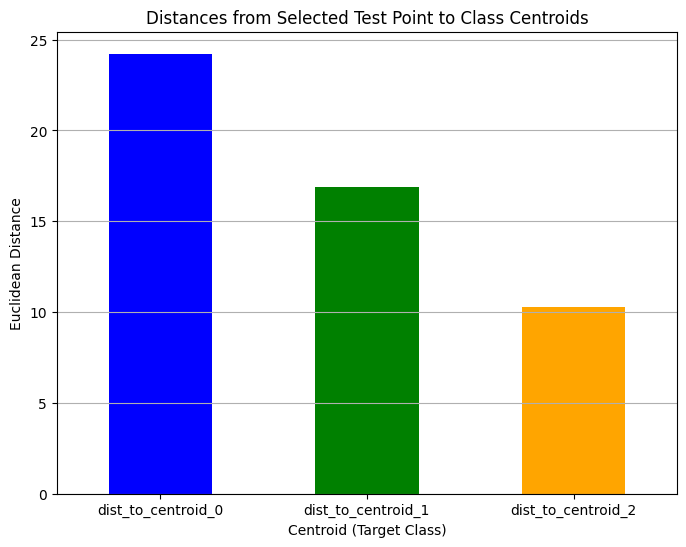

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# -------------------------------------------------------------------
# Step 16: Visualize distances from a single augmented test point to centroids
# -------------------------------------------------------------------
print("\n=== Visualizing distances from a test point to centroids ===")

# Select a single test point from the augmented test set (e.g., the first one)
# Use X_test_augmented_centroid as it already contains distances to centroids
test_point_augmented = X_test_augmented_centroid.iloc[0]
test_point_original_features = test_point_augmented[top_features] # Original features of the test point

print(f"\nSelected Test Point (Augmented Features):\n{test_point_augmented.to_string()}")

# Extract centroid distances from the augmented test point
dist_to_centroid_cols = [col for col in X_test_augmented_centroid.columns if 'dist_to_centroid' in col]
test_point_centroid_distances = test_point_augmented[dist_to_centroid_cols]

print(f"\nDistances from the test point to each centroid:\n{test_point_centroid_distances.to_string()}")

# Visualize the distances as a bar chart
plt.figure(figsize=(8, 6))
test_point_centroid_distances.plot(kind='bar', color=['blue', 'green', 'orange']) # Assuming 3 classes/centroids
plt.title('Distances from Selected Test Point to Class Centroids')
plt.xlabel('Centroid (Target Class)')
plt.ylabel('Euclidean Distance')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

# Optional: Visualize the test point and centroids in 2D PCA space of original features (if helpful)
# This requires re-running PCA if not already done, or using the existing pca object
# We already have pca object from cell tcPrZVmmi5dm

if 'pca' in locals():
    print("\n=== Visualizing Test Point and Centroids in 2D PCA Space (Original Features) ===")

    # Transform the selected test point (original features only) using the fitted PCA
    test_point_pca = pca.transform(test_point_original_features.values.reshape(1, -1))

    # Transform centroids using the same PCA (already done in cell tcPrZVmmi5dm, but doing again for clarity)
    centroids_pca = pca.transform(centroids)

    plt.figure(figsize=(10, 8))

    # Plot data points (optional, can be too crowded)
    # sns.scatterplot(x='PCA1', y='PCA2', hue='target', data=pca_df, palette='viridis', s=50)

    # Plot Centroids
    plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c=['blue', 'green', 'orange'], s=300, alpha=0.8, marker='o', label='Centroids')

    # Highlight the selected test point
    plt.scatter(test_point_pca[:, 0], test_point_pca[:, 1], c='red', s=500, alpha=1.0, marker='*', label='Selected Test Point')

    plt.title('Test Point and Centroids in 2D PCA Space (Original Features)')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.legend()
    plt.grid(True)
    plt.show()


=== Visualizing a Test Point and Centroids in 3D Space (Original Features) ===


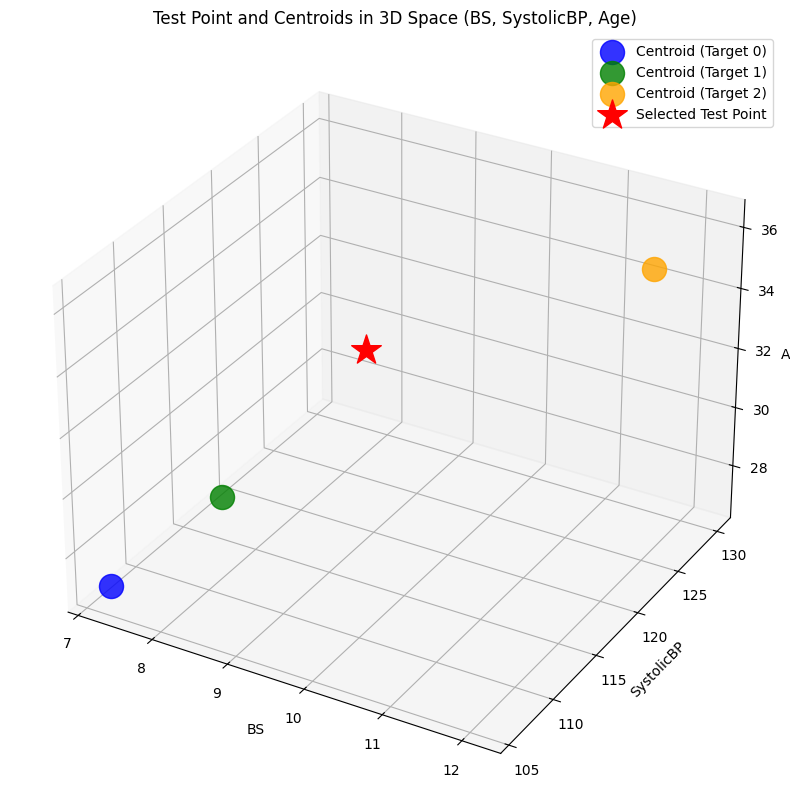

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# -------------------------------------------------------------------
# Step 17: Visualize a Test Point and Centroids in 3D Space (Original Features)
# -------------------------------------------------------------------
print("\n=== Visualizing a Test Point and Centroids in 3D Space (Original Features) ===")

# Use the top 3 features as the axes for the 3D plot
feature1 = top_features[0]
feature2 = top_features[1]
feature3 = top_features[2]

# Assuming 'test_point_original_features' and 'centroids' are available from previous steps
# Select a single test point (e.g., the first one from X_test_filtered) if not already defined
if 'test_point_original_features' not in locals():
    test_point_original_features = X_test_filtered.iloc[0][top_features]

# Get centroid coordinates for plotting
centroids_plot = centroids[top_features]


fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot Centroids
# Assuming centroids are indexed by target class (0, 1, 2)
centroid_colors = ['blue', 'green', 'orange'] # Assign colors to classes
for i, target_class in enumerate(centroids_plot.index):
    ax.scatter(centroids_plot.loc[target_class, feature1],
               centroids_plot.loc[target_class, feature2],
               centroids_plot.loc[target_class, feature3],
               c=centroid_colors[i], s=300, alpha=0.8, marker='o', label=f'Centroid (Target {target_class})')

# Plot the selected Test Point
ax.scatter(test_point_original_features[feature1],
           test_point_original_features[feature2],
           test_point_original_features[feature3],
           c='red', s=500, alpha=1.0, marker='*', label='Selected Test Point')

ax.set_title(f'Test Point and Centroids in 3D Space ({feature1}, {feature2}, {feature3})')
ax.set_xlabel(feature1)
ax.set_ylabel(feature2)
ax.set_zlabel(feature3)

ax.legend()
plt.show()


=== Visualizing Augmented Test Point in 3D PCA Space (Augmented Features) ===


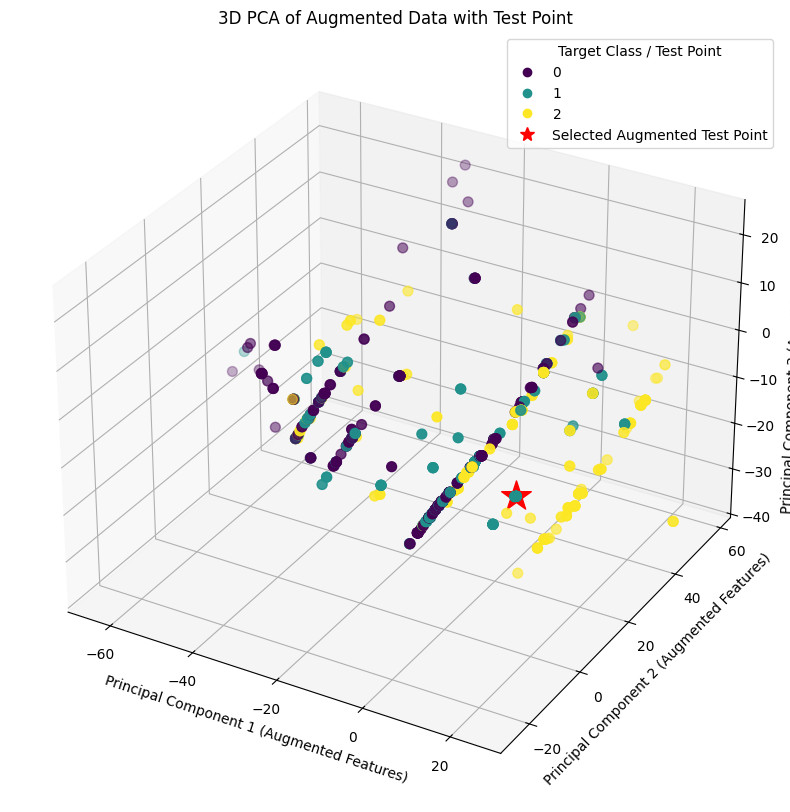

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D # Ensure this is imported for 3D plots

# -------------------------------------------------------------------
# Step 18: Visualize Augmented Test Point in 3D PCA Space of Augmented Features
# -------------------------------------------------------------------
print("\n=== Visualizing Augmented Test Point in 3D PCA Space (Augmented Features) ===")

# We need the PCA object fitted on the augmented training data (from cell nG6DVgFDnLqY)
# And the augmented test data point itself (e.g., the first one from X_test_augmented_medoid)

# Ensure pca_augmented_3d and pca_augmented_train_df_3d exist from cell nG6DVgFDnLqY
if 'pca_augmented_3d' not in locals() or 'pca_augmented_train_df_3d' not in locals():
    print("Running PCA on augmented training data to get the transformation...")
    pca_augmented_3d = PCA(n_components=3, random_state=42)
    X_pca_augmented_train_3d = pca_augmented_3d.fit_transform(X_train_augmented_medoid)
    pca_augmented_train_df_3d = pd.DataFrame(data=X_pca_augmented_train_3d, columns=['PCA1', 'PCA2', 'PCA3'])
    pca_augmented_train_df_3d['target'] = y_train.reset_index(drop=True)

# Select an augmented test point (e.g., the first one from X_test_augmented_medoid)
# Ensure X_test_augmented_medoid exists
if 'X_test_augmented_medoid' not in locals():
     print("X_test_augmented_medoid not found. Cannot visualize test point.")
else:
    # Assuming we want to visualize the same test point used in the centroid distance plot (cell 3XgsmtbDoaVu)
    # We need its row index in the original X_test_filtered
    if 'test_point_augmented' in locals():
        test_point_original_index = test_point_augmented.name # Get the original index
        test_point_augmented_features = X_test_augmented_medoid.loc[[test_point_original_index]] # Get the row from the augmented test data
    else:
         # If test_point_augmented is not defined, just use the first test point
         print("Using the first test point from X_test_augmented_medoid as the example.")
         test_point_augmented_features = X_test_augmented_medoid.iloc[[0]]


    # Transform the selected augmented test point using the fitted PCA
    test_point_pca_3d = pca_augmented_3d.transform(test_point_augmented_features)


    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    # Plot augmented training data points (from cell nG6DVgFDnLqY)
    scatter_aug_3d = ax.scatter(pca_augmented_train_df_3d['PCA1'],
                                pca_augmented_train_df_3d['PCA2'],
                                pca_augmented_train_df_3d['PCA3'],
                                c=pca_augmented_train_df_3d['target'],
                                cmap='viridis',
                                s=50,
                                label='Augmented Training Data') # Add label for combined legend

    # Plot the selected augmented test point
    ax.scatter(test_point_pca_3d[:, 0], test_point_pca_3d[:, 1], test_point_pca_3d[:, 2],
               c='red', s=500, alpha=1.0, marker='*', label='Selected Augmented Test Point')


    ax.set_title('3D PCA of Augmented Data with Test Point')
    ax.set_xlabel('Principal Component 1 (Augmented Features)')
    ax.set_ylabel('Principal Component 2 (Augmented Features)')
    ax.set_zlabel('Principal Component 3 (Augmented Features)')

    # Create a combined legend
    handles, labels = scatter_aug_3d.legend_elements()
    # Add handle and label for the test point
    handles.append(plt.Line2D([], [], color='red', marker='*', linestyle='None', markersize=10))
    labels.append('Selected Augmented Test Point')
    ax.legend(handles=handles, labels=labels, title='Target Class / Test Point')

    plt.show()


=== Visualizing 3D PCA of Test Data with Centroids ===
Running 3D PCA on original training data to get the transformation...


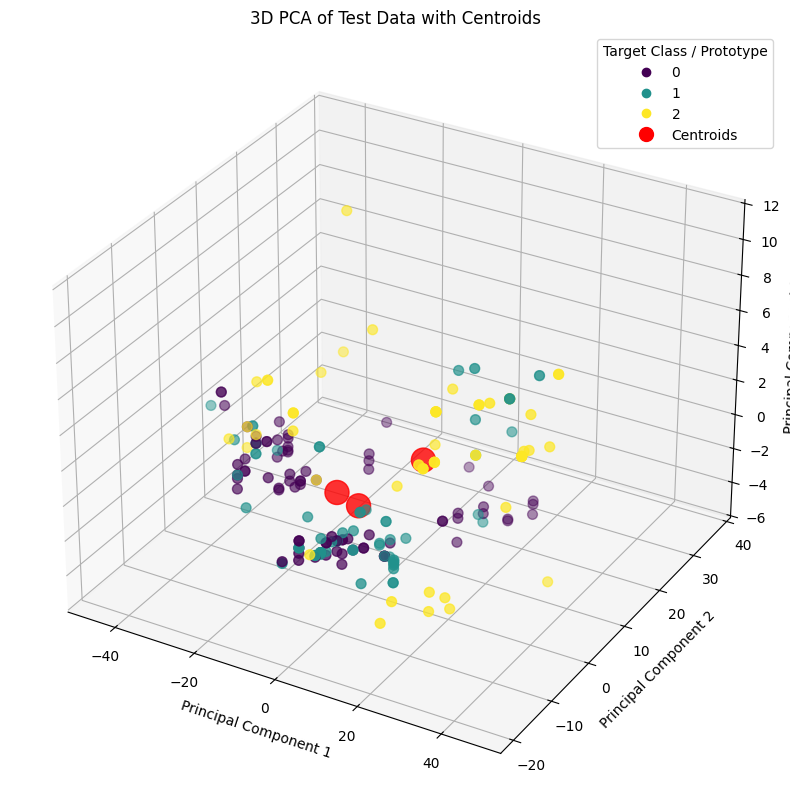

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA
import numpy as np

# -------------------------------------------------------------------
# Step 19: Visualize 3D PCA of Test Data with Centroids
# -------------------------------------------------------------------
print("\n=== Visualizing 3D PCA of Test Data with Centroids ===")

# We need the PCA object fitted on the training data (from cell rrK9n_Qijqh2 or earlier 3D PCA)
# Let's ensure we use the PCA fitted on the ORIGINAL training data for consistency with centroid transformation
if 'pca_3d' not in locals():
    print("Running 3D PCA on original training data to get the transformation...")
    pca_3d = PCA(n_components=3, random_state=42)
    # Fit PCA on the original X_train (top_features)
    pca_3d.fit(X_train_filtered)


# Transform the test data using the fitted PCA
X_pca_test_3d = pca_3d.transform(X_test_filtered)

# Create a DataFrame for easier plotting
pca_test_df_3d = pd.DataFrame(data=X_pca_test_3d, columns=['PCA1', 'PCA2', 'PCA3'])
pca_test_df_3d['target'] = y_test.reset_index(drop=True) # Reset index to align with PCA results


fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot test data points, colored by target
scatter_test_3d = ax.scatter(pca_test_df_3d['PCA1'],
                             pca_test_df_3d['PCA2'],
                             pca_test_df_3d['PCA3'],
                             c=pca_test_df_3d['target'],
                             cmap='viridis',
                             s=50,
                             label='Test Data') # Add label for combined legend

# Transform centroids using the same 3D PCA
if 'centroids' not in locals():
    print("Centroids not found. Cannot plot centroids.")
    centroids_pca_3d = None
else:
    centroids_pca_3d = pca_3d.transform(centroids)


# Plot Centroids in 3D if available
if centroids_pca_3d is not None:
    ax.scatter(centroids_pca_3d[:, 0], centroids_pca_3d[:, 1], centroids_pca_3d[:, 2],
               c='red', s=300, alpha=0.8, marker='o', label='Centroids')


ax.set_title('3D PCA of Test Data with Centroids')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')

# Create a combined legend
handles, labels = scatter_test_3d.legend_elements()
# Add handle and label for centroids if plotted
if centroids_pca_3d is not None:
    handles.append(plt.Line2D([], [], color='red', marker='o', linestyle='None', markersize=10))
    labels.append('Centroids')

ax.legend(handles=handles, labels=labels, title='Target Class / Prototype')


plt.show()


=== Visualizing the clusters ===


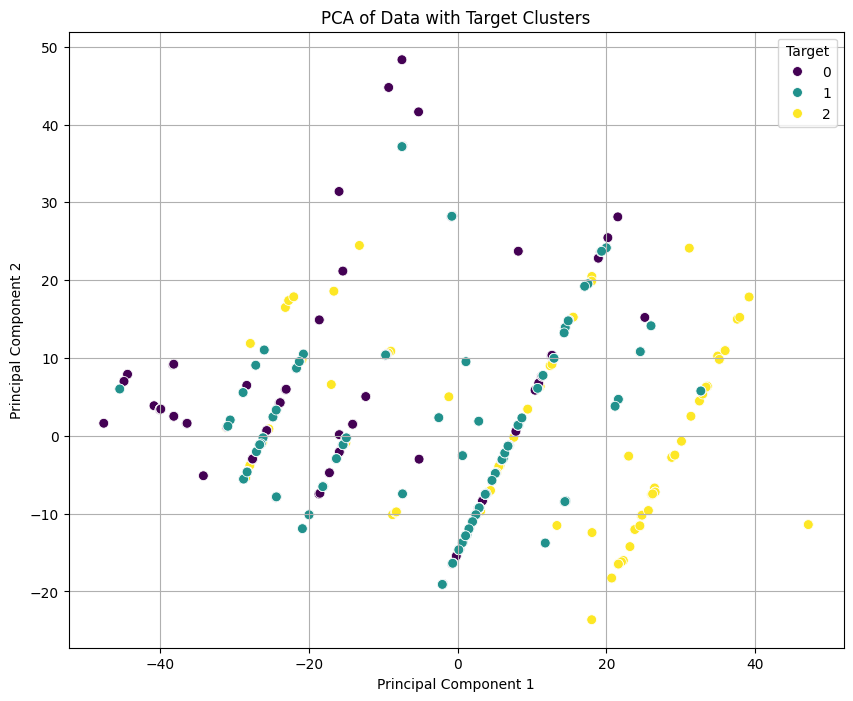

TypeError: seaborn.utils._scatter_legend_artist() got multiple values for keyword argument 'label'

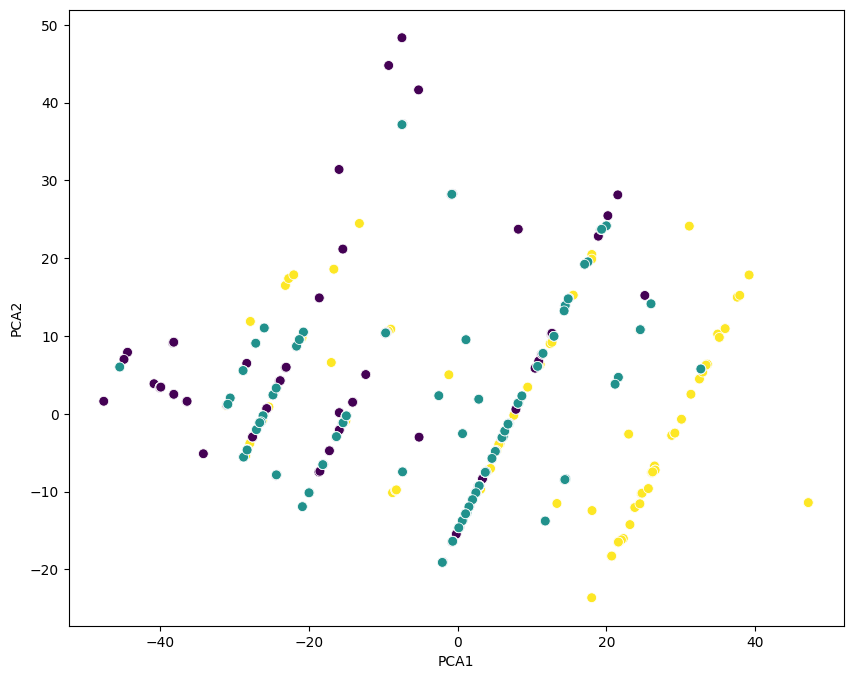

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# ---------------------------
# Step 9: Visualize the clusters
# ---------------------------
print("\n=== Visualizing the clusters ===")

# Use PCA to reduce the data to 2 dimensions for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X[top_features])

# Create a DataFrame for easier plotting
pca_df = pd.DataFrame(data=X_pca, columns=['PCA1', 'PCA2'])
pca_df['target'] = y.values

# Visualize the clusters based on the original target variable
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PCA1', y='PCA2', hue='target', data=pca_df, palette='viridis', s=50)
plt.title('PCA of Data with Target Clusters')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Target')
plt.grid(True)
plt.show()

# You can also visualize the medoids and centroids on this plot
# Need to transform medoids and centroids using the same PCA
medoids_pca = pca.transform(medoids_df)
centroids_pca = pca.transform(centroids)

plt.figure(figsize=(10, 8))
sns.scatterplot(x='PCA1', y='PCA2', hue='target', data=pca_df, palette='viridis', s=50, label='Data Points')
plt.scatter(medoids_pca[:, 0], medoids_pca[:, 1], c='red', s=200, alpha=0.7, label='Medoids', marker='X')
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='black', s=200, alpha=0.7, label='Centroids', marker='o')

plt.title('PCA of Data with Target Clusters, Medoids, and Centroids')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Target / Prototype')
plt.grid(True)
plt.show()


=== Visualizing in 3D ===


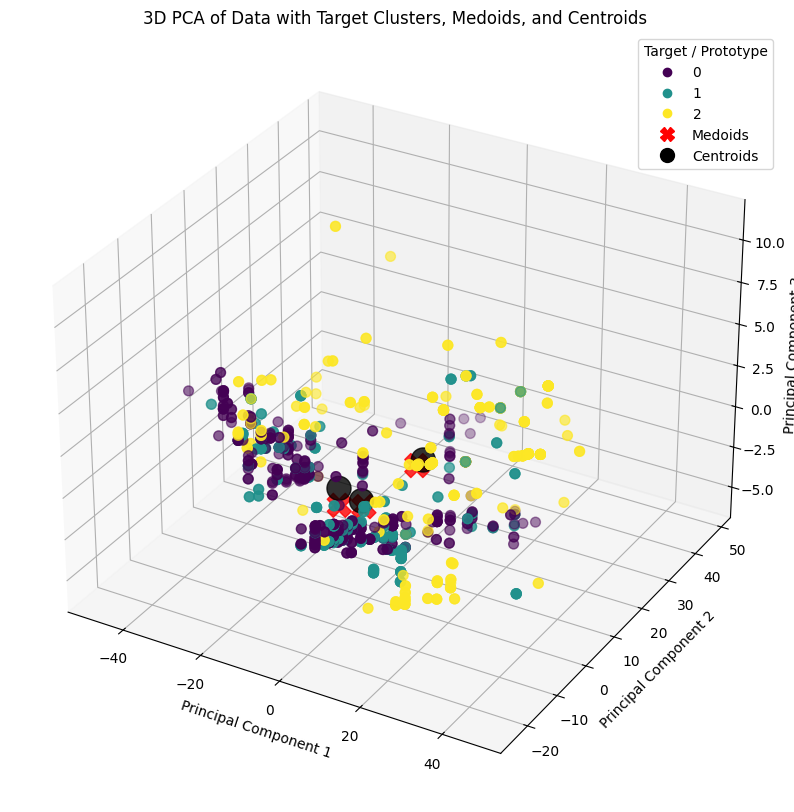

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import numpy as np

# ---------------------------
# Step 10: Visualize in 3D
# ---------------------------
print("\n=== Visualizing in 3D ===")

# Use PCA to reduce the data to 3 dimensions for visualization
pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(X[top_features])

# Create a DataFrame for easier plotting
pca_df_3d = pd.DataFrame(data=X_pca_3d, columns=['PCA1', 'PCA2', 'PCA3'])
pca_df_3d['target'] = y.values

# Visualize the clusters based on the original target variable in 3D
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot data points
scatter_3d = ax.scatter(pca_df_3d['PCA1'], pca_df_3d['PCA2'], pca_df_3d['PCA3'],
                        c=pca_df_3d['target'], cmap='viridis', s=50, label='Data Points')

# Transform medoids and centroids using the same 3D PCA
medoids_pca_3d = pca_3d.transform(medoids_df)
centroids_pca_3d = pca_3d.transform(centroids)

# Plot Medoids in 3D
ax.scatter(medoids_pca_3d[:, 0], medoids_pca_3d[:, 1], medoids_pca_3d[:, 2],
           c='red', s=300, alpha=0.8, marker='X', label='Medoids')

# Plot Centroids in 3D
ax.scatter(centroids_pca_3d[:, 0], centroids_pca_3d[:, 1], centroids_pca_3d[:, 2],
           c='black', s=300, alpha=0.8, marker='o', label='Centroids')

ax.set_title('3D PCA of Data with Target Clusters, Medoids, and Centroids')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')

# Create a combined legend
# Get handles and labels for the scatterplot (target classes)
handles, labels = scatter_3d.legend_elements()
# Add handles and labels for medoids and centroids
handles.extend([
    plt.Line2D([], [], color='red', marker='X', linestyle='None', markersize=10),
    plt.Line2D([], [], color='black', marker='o', linestyle='None', markersize=10)
])
labels.extend(['Medoids', 'Centroids'])
ax.legend(handles=handles, labels=labels, title='Target / Prototype')


plt.show()


=== Visualizing Decision Boundaries (Direct RF) ===


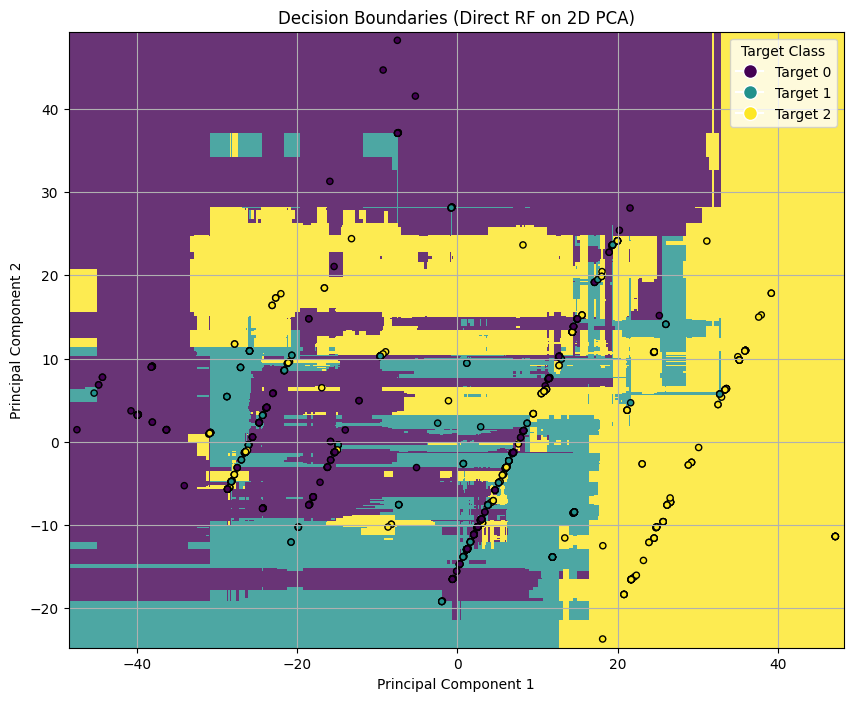

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier # Import RandomForestClassifier

# ---------------------------
# Step 11: Visualize Decision Boundaries (using Direct RF and 2D PCA)
# ---------------------------
print("\n=== Visualizing Decision Boundaries (Direct RF) ===")

# Use PCA to reduce the data to 2 dimensions
pca = PCA(n_components=2, random_state=42)
X_pca_train = pca.fit_transform(X_train_filtered)
X_pca_test = pca.transform(X_test_filtered)

# Train a simple RF on 2D PCA data for visualization purposes
# (This is different from the previous RF models, trained on original/augmented features)
rf_2d = RandomForestClassifier(n_estimators=100, random_state=42)
rf_2d.fit(X_pca_train, y_train)


# Create a mesh to plot the decision boundaries
x_min, x_max = X_pca_train[:, 0].min() - 1, X_pca_train[:, 0].max() + 1
y_min, y_max = X_pca_train[:, 1].min() - 1, X_pca_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

# Predict the class for each point in the mesh
Z = rf_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the contour and the data points
plt.figure(figsize=(10, 8))
# Use pcolormesh for filled contours
plt.pcolormesh(xx, yy, Z, cmap=plt.cm.viridis, shading='auto', alpha=0.8)

# Plot also the training points with explicit labels for the legend
scatter = plt.scatter(X_pca_train[:, 0], X_pca_train[:, 1], c=y_train, cmap=plt.cm.viridis, edgecolor='k', s=20, label='Data Points')

plt.title('Decision Boundaries (Direct RF on 2D PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

# Create a legend mapping colors to target classes
# Get unique target values and create a legend
unique_targets = np.unique(y_train)
# Need to manually create handles/labels for the legend based on unique target values
legend_handles = []
for target_val in unique_targets:
    # Find the corresponding color from the colormap
    color = plt.cm.viridis((target_val - min(unique_targets)) / (max(unique_targets) - min(unique_targets)))
    legend_handles.append(plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=f'Target {target_val}'))

plt.legend(handles=legend_handles, title='Target Class')

plt.grid(True)
plt.show()


=== Visualizing Predictions of Medoid-Augmented RF (3D PCA of Augmented Features) ===


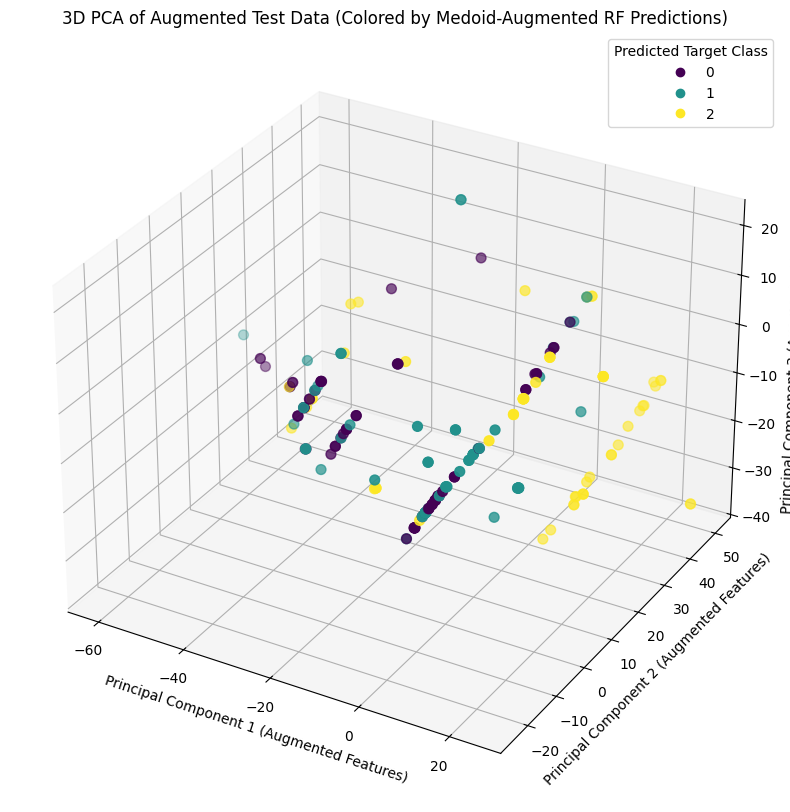

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA
import numpy as np
from sklearn.ensemble import RandomForestClassifier

# -------------------------------------------------------------------
# Step 20: Visualize Predictions of Medoid-Augmented RF (3D PCA of Augmented Features)
# -------------------------------------------------------------------
print("\n=== Visualizing Predictions of Medoid-Augmented RF (3D PCA of Augmented Features) ===")

# We need the PCA object fitted on the augmented training data (from cell nG6DVgFDnLqY or YZvPARk7pQqu)
# Let's ensure pca_augmented_3d is fitted on X_train_augmented_medoid
if 'pca_augmented_3d' not in locals() or not hasattr(pca_augmented_3d, 'mean_'):
    print("Running PCA on augmented training data to get the transformation...")
    pca_augmented_3d = PCA(n_components=3, random_state=42)
    pca_augmented_3d.fit(X_train_augmented_medoid)


# Transform the test data using the fitted augmented PCA
X_pca_augmented_test_3d = pca_augmented_3d.transform(X_test_augmented_medoid)

# Predict on the augmented test data using the medoid-augmented RF model
if 'rf_augmented_medoid' not in locals():
    print("Medoid-augmented RF model not found. Cannot visualize predictions.")
    y_pred_augmented_medoid_test = None
else:
    y_pred_augmented_medoid_test = rf_augmented_medoid.predict(X_test_augmented_medoid)


if y_pred_augmented_medoid_test is not None:
    # Create a DataFrame for easier plotting
    pca_augmented_test_df_3d = pd.DataFrame(data=X_pca_augmented_test_3d, columns=['PCA1', 'PCA2', 'PCA3'])
    pca_augmented_test_df_3d['predicted_target'] = y_pred_augmented_medoid_test

    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    # Plot test data points, colored by predicted target
    scatter_pred_aug_3d = ax.scatter(pca_augmented_test_df_3d['PCA1'],
                                    pca_augmented_test_df_3d['PCA2'],
                                    pca_augmented_test_df_3d['PCA3'],
                                    c=pca_augmented_test_df_3d['predicted_target'],
                                    cmap='viridis', # Using the same colormap for consistency
                                    s=50)

    ax.set_title('3D PCA of Augmented Test Data (Colored by Medoid-Augmented RF Predictions)')
    ax.set_xlabel('Principal Component 1 (Augmented Features)')
    ax.set_ylabel('Principal Component 2 (Augmented Features)')
    ax.set_zlabel('Principal Component 3 (Augmented Features)')

    # Create a legend mapping colors to predicted target classes
    handles, labels = scatter_pred_aug_3d.legend_elements()
    ax.legend(handles=handles, labels=labels, title='Predicted Target Class')

    plt.show()
else:
    print("Could not generate prediction visualization.")


=== Visualizing Raw Data (Top 3 Features) in 3D ===


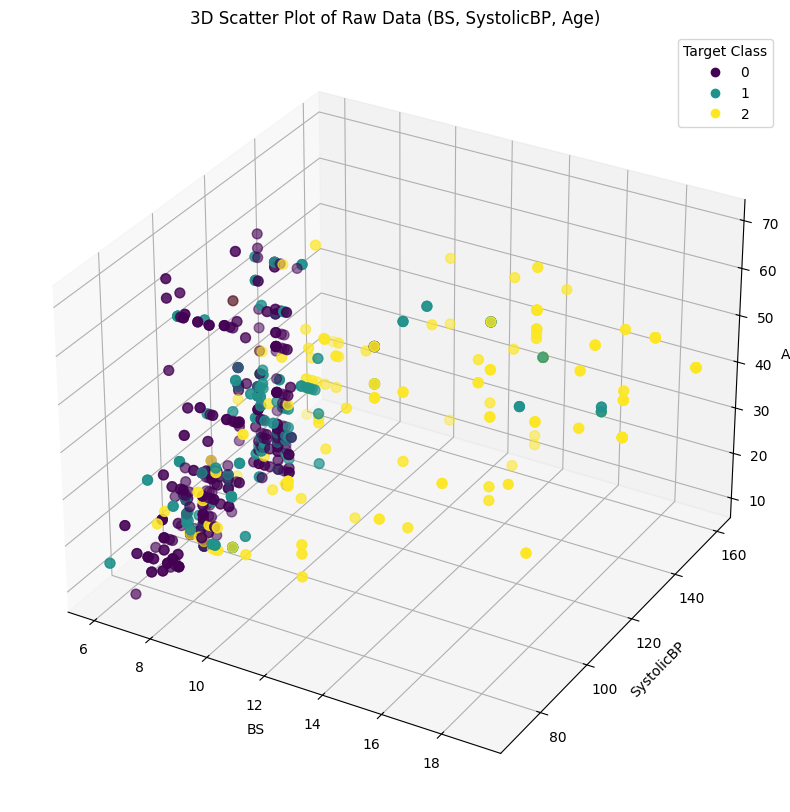

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ---------------------------
# Step 12: Visualize Raw Data (Top 3 Features) in 3D
# ---------------------------
print("\n=== Visualizing Raw Data (Top 3 Features) in 3D ===")

# Use the top 3 features directly for 3D plotting
feature1 = top_features[0]
feature2 = top_features[1]
feature3 = top_features[2]

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot data points, colored by target
scatter_raw_3d = ax.scatter(df[feature1], df[feature2], df[feature3],
                            c=df['target'], cmap='viridis', s=50)

ax.set_title(f'3D Scatter Plot of Raw Data ({feature1}, {feature2}, {feature3})')
ax.set_xlabel(feature1)
ax.set_ylabel(feature2)
ax.set_zlabel(feature3)

# Create a legend mapping colors to target classes
# Get handles and labels for the scatterplot (target classes)
handles, labels = scatter_raw_3d.legend_elements()
ax.legend(handles=handles, labels=labels, title='Target Class')

plt.show()


=== Visualizing Decision Boundaries, Clusters, and Medoids ===


AttributeError: 'PathCollection' object has no attribute 'get_legend_handles_labels'

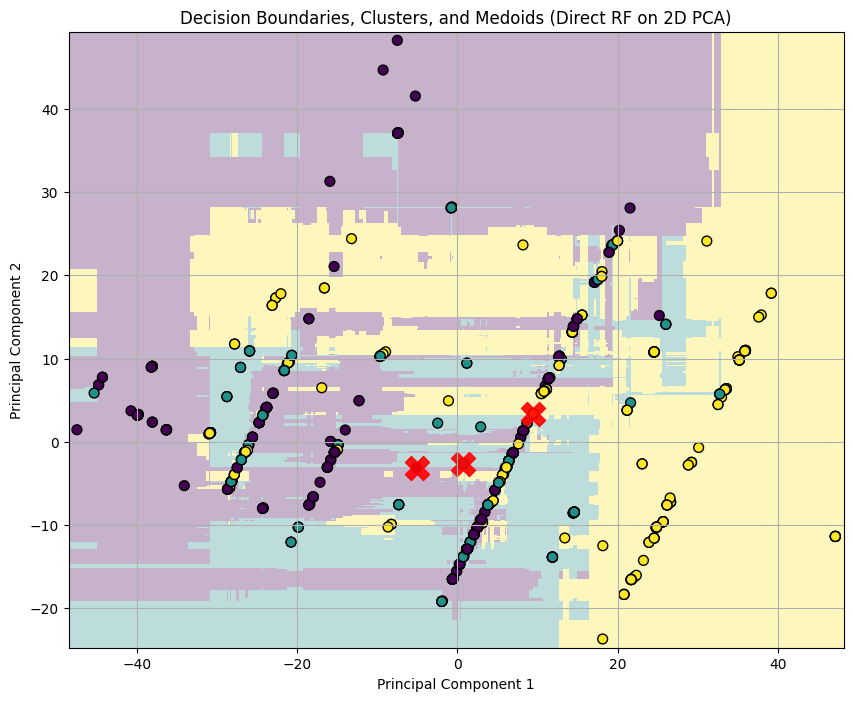

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier

# ---------------------------
# Step 13: Visualize Decision Boundaries, Clusters, and Medoids (2D PCA)
# ---------------------------
print("\n=== Visualizing Decision Boundaries, Clusters, and Medoids ===")

# Use PCA to reduce the data to 2 dimensions
pca = PCA(n_components=2, random_state=42)
X_pca_train = pca.fit_transform(X_train_filtered)
X_pca_test = pca.transform(X_test_filtered) # Although not used for boundary plotting, good practice to transform test set too

# Train a simple RF on 2D PCA data for visualization purposes
rf_2d = RandomForestClassifier(n_estimators=100, random_state=42)
rf_2d.fit(X_pca_train, y_train)

# Create a mesh to plot the decision boundaries
x_min, x_max = X_pca_train[:, 0].min() - 1, X_pca_train[:, 0].max() + 1
y_min, y_max = X_pca_train[:, 1].min() - 1, X_pca_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

# Predict the class for each point in the mesh
Z = rf_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the contour (decision regions)
plt.figure(figsize=(10, 8))
# Using a perceptually uniform colormap that is often considered "mild"
cmap_mild = plt.cm.viridis
plt.pcolormesh(xx, yy, Z, cmap=cmap_mild, shading='auto', alpha=0.3) # Lower alpha for mild colors

# Plot the data points (clusters)
scatter = plt.scatter(X_pca_train[:, 0], X_pca_train[:, 1], c=y_train, cmap=cmap_mild, edgecolor='k', s=50, label='Data Points')

# Transform medoids using the same PCA
medoids_pca = pca.transform(medoids_df)

# Plot Medoids
plt.scatter(medoids_pca[:, 0], medoids_pca[:, 1], c='red', s=300, alpha=0.9, marker='X', label='Medoids')

plt.title('Decision Boundaries, Clusters, and Medoids (Direct RF on 2D PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)

# Create a combined legend
handles, labels = scatter.get_legend_handles_labels()
# Add handle and label for medoids
handles.append(plt.Line2D([], [], color='red', marker='X', linestyle='None', markersize=10))
labels.append('Medoids')

plt.legend(handles=handles, labels=labels, title='Legend')

plt.show()


=== Visualizing the 3 Clusters ===


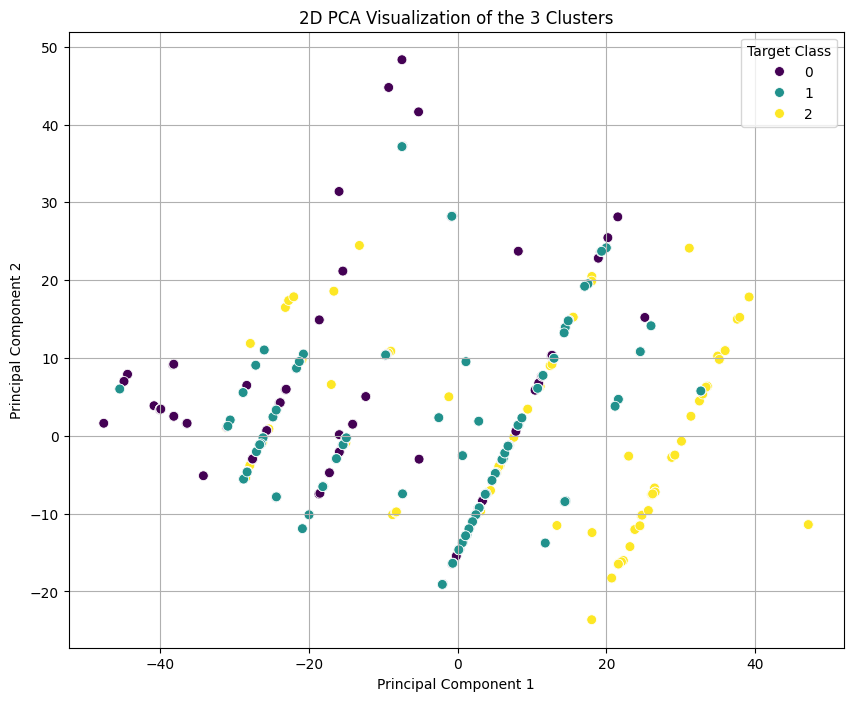

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import pandas as pd

# ---------------------------
# Step 21: Visualize the 3 Clusters (2D PCA)
# ---------------------------
print("\n=== Visualizing the 3 Clusters ===")

# Use PCA to reduce the data to 2 dimensions for visualization
pca_clusters = PCA(n_components=2, random_state=42)
X_pca_clusters = pca_clusters.fit_transform(X[top_features]) # Use original X with filtered features

# Create a DataFrame for easier plotting
pca_clusters_df = pd.DataFrame(data=X_pca_clusters, columns=['PCA1', 'PCA2'])
pca_clusters_df['target'] = y.values # Use original y values for coloring

# Visualize the clusters based on the original target variable
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PCA1', y='PCA2', hue='target', data=pca_clusters_df, palette='viridis', s=50)
plt.title('2D PCA Visualization of the 3 Clusters')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Target Class')
plt.grid(True)
plt.show()


=== Visualizing Augmented Test Point and Medoids with Distance Lines (3D PCA of Augmented Features) ===


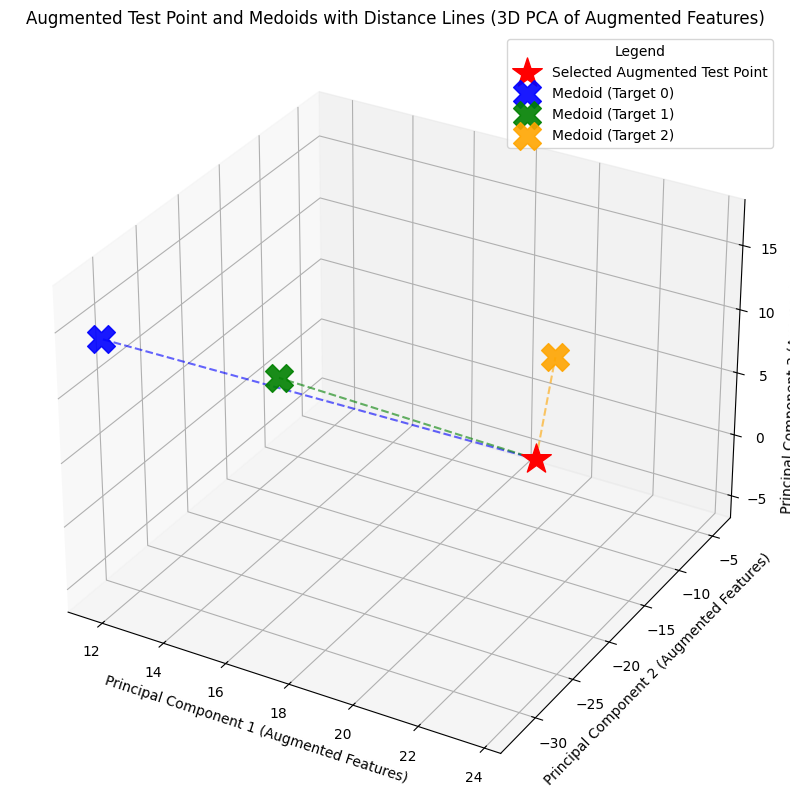

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA

# -------------------------------------------------------------------
# Step 22: Visualize Augmented Test Point and Medoids with Distance Lines (3D PCA of Augmented Features)
# -------------------------------------------------------------------
print("\n=== Visualizing Augmented Test Point and Medoids with Distance Lines (3D PCA of Augmented Features) ===")

# We need the PCA object fitted on the augmented training data (from cell YZvPARk7pQqu)
# And the augmented test data point's PCA coordinates (from cell YZvPARk7pQqu)
# And the medoids transformed into the augmented PCA space (from cell YZvPARk7pQqu logic)

# Ensure pca_augmented_3d is fitted on X_train_augmented_medoid
if 'pca_augmented_3d' not in locals() or not hasattr(pca_augmented_3d, 'mean_'):
    print("Running PCA on augmented training data to get the transformation...")
    pca_augmented_3d = PCA(n_components=3, random_state=42)
    # Need the data used to fit it initially, which is X_train_augmented_medoid
    if 'X_train_augmented_medoid' in locals():
        pca_augmented_3d.fit(X_train_augmented_medoid)
    else:
        print("X_train_augmented_medoid not found. Cannot fit PCA. Skipping visualization.")
        # Exit the visualization attempt if data is missing
        # (Alternatively, could try refitting PCA if data is available elsewhere, but this is safer)
        pca_augmented_3d = None


# Get the augmented test point's PCA coordinates
test_point_pca_3d = None # Initialize to None
if pca_augmented_3d is not None and 'X_test_augmented_medoid' in locals():
    # Assuming we want to visualize the same test point as before (from cell 3XgsmtbDoaVu)
    if 'test_point_augmented' in locals():
        test_point_original_index = test_point_augmented.name
        if test_point_original_index in X_test_augmented_medoid.index:
             test_point_augmented_features = X_test_augmented_medoid.loc[[test_point_original_index]]
        else:
             print(f"Test point with original index {test_point_original_index} not found in X_test_augmented_medoid. Using the first test point instead.")
             test_point_augmented_features = X_test_augmented_medoid.iloc[[0]]
    else:
         print("Using the first test point from X_test_augmented_medoid as the example.")
         test_point_augmented_features = X_test_augmented_medoid.iloc[[0]]

    # Transform the selected augmented test point using the fitted PCA
    test_point_pca_3d = pca_augmented_3d.transform(test_point_augmented_features)
else:
     if pca_augmented_3d is not None:
          print("X_test_augmented_medoid not found. Cannot visualize test point.")


# Get the medoids transformed into the augmented PCA space
centroids_pca_augmented_3d = None # Renaming from centroids_pca_augmented_3d for clarity with medoids
if pca_augmented_3d is not None and 'medoids_df' in locals() and 'X_train_augmented_medoid' in locals():
    # Create a DataFrame for medoids with the same columns as X_train_augmented_medoid
    # Fill distance columns with 0s, as medoids are defined in the original feature space
    # Correction: Medoids are also points in the ORIGINAL feature space. The distances are zero *if* the point is the medoid itself.
    # To represent medoids in the AUGMENTED PCA space, we need to create augmented feature vectors FOR the medoids
    # The augmented features for a medoid M would be: [M_features, dist(M, M_proto1), dist(M, M_proto2), ...]
    # We need the original feature values for the medoids AND calculate their distances to the medoid prototypes.
    # This is complex. A simpler approach is to transform the original medoid feature vectors using the PCA fitted on augmented data,
    # acknowledging this might not perfectly represent the 'medoid' concept in the augmented space but provides a point for visualization.
    # Let's try transforming the original medoid features using the augmented PCA.
    # This is the approach used previously for centroids in YZvPARk7pQqu, despite the "ValueError" which was due to column names.

    # Let's assume medoids_df has the original features.
    if all(col in medoids_df.columns for col in top_features):
         # Create a DataFrame for medoids with the same columns as X_train_augmented_medoid
         # Fill distance columns with 0s (representing the medoids themselves)
         medoids_augmented_format = pd.DataFrame(0.0, index=medoids_df.index, columns=X_train_augmented_medoid.columns)
         medoids_augmented_format[top_features] = medoids_df[top_features]

         # Transform this augmented-format medoid data using the PCA fitted on augmented data
         medoids_pca_augmented_3d = pca_augmented_3d.transform(medoids_augmented_format)

    else:
         print("Medoids_df does not contain top_features. Cannot transform medoids into augmented PCA space.")

else:
     if pca_augmented_3d is not None:
          print("Medoids_df or X_train_augmented_medoid not found. Cannot plot medoids in augmented PCA space.")


# --- Plotting ---
if test_point_pca_3d is not None and medoids_pca_augmented_3d is not None:

    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    # Plot the selected augmented test point
    ax.scatter(test_point_pca_3d[:, 0], test_point_pca_3d[:, 1], test_point_pca_3d[:, 2],
               c='red', s=500, alpha=1.0, marker='*', label='Selected Augmented Test Point')


    # Plot Medoids in 3D (transformed into augmented PCA space)
    medoid_colors = ['blue', 'green', 'orange'] # Assign colors to classes
    medoid_labels = [f'Medoid (Target {i})' for i in medoids_df.index]

    for i in range(medoids_pca_augmented_3d.shape[0]):
         ax.scatter(medoids_pca_augmented_3d[i, 0],
                   medoids_pca_augmented_3d[i, 1],
                   medoids_pca_augmented_3d[i, 2],
                   c=medoid_colors[i], s=400, alpha=0.9, marker='X', label=medoid_labels[i])

         # Draw lines connecting the test point to each medoid
         # Correct format for ax.plot: list of x-coords, list of y-coords, list of z-coords
         ax.plot([test_point_pca_3d[0, 0], medoids_pca_augmented_3d[i, 0]],
                 [test_point_pca_3d[0, 1], medoids_pca_augmented_3d[i, 1]],
                 [test_point_pca_3d[0, 2], medoids_pca_augmented_3d[i, 2]],
                 c=medoid_colors[i], linestyle='--', alpha=0.6)


    ax.set_title('Augmented Test Point and Medoids with Distance Lines (3D PCA of Augmented Features)')
    ax.set_xlabel('Principal Component 1 (Augmented Features)')
    ax.set_ylabel('Principal Component 2 (Augmented Features)')
    ax.set_zlabel('Principal Component 3 (Augmented Features)')

    # Create a combined legend
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles, labels=labels, title='Legend')

    plt.show()
else:
     print("Could not generate visualization. Check if PCA, test point, and medoids are available.")


=== Visualizing Predicted Regions of Medoid-Augmented RF (2D PCA of Augmented Features) ===
Running 2D PCA on augmented training data to get the transformation...
Training a 2D RF on augmented PCA data for visualization...


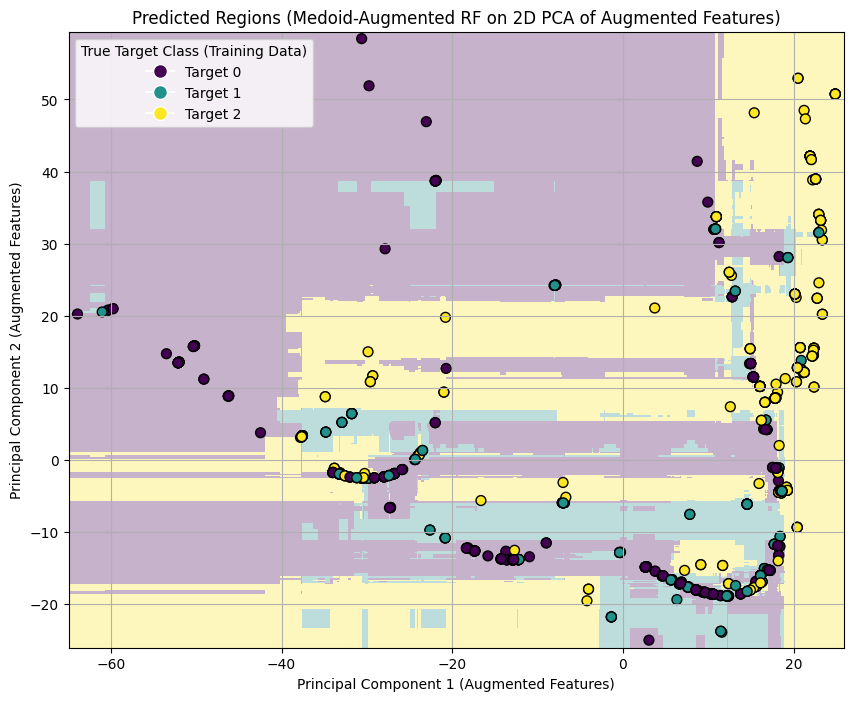

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier

# ---------------------------
# Step 23: Visualize Predicted Regions of Medoid-Augmented RF (2D PCA of Augmented Features)
# ---------------------------
print("\n=== Visualizing Predicted Regions of Medoid-Augmented RF (2D PCA of Augmented Features) ===")

# We need the PCA object fitted on the augmented training data
if 'pca_augmented' not in locals() or not hasattr(pca_augmented, 'mean_'):
     print("Running 2D PCA on augmented training data to get the transformation...")
     pca_augmented = PCA(n_components=2, random_state=42)
     if 'X_train_augmented_medoid' in locals():
         X_pca_augmented_train = pca_augmented.fit_transform(X_train_augmented_medoid)
     else:
         print("X_train_augmented_medoid not found. Cannot perform PCA for visualization.")
         X_pca_augmented_train = None


# We need the medoid-augmented RF model trained on 2D PCA of augmented features for plotting
if 'rf_2d_augmented_medoid' not in locals() or not hasattr(rf_2d_augmented_medoid, 'predict'):
     print("Training a 2D RF on augmented PCA data for visualization...")
     if X_pca_augmented_train is not None and 'y_train' in locals():
         rf_2d_augmented_medoid = RandomForestClassifier(n_estimators=100, random_state=42)
         rf_2d_augmented_medoid.fit(X_pca_augmented_train, y_train)
     else:
         print("Required data (X_pca_augmented_train, y_train) not found. Cannot train 2D RF.")
         rf_2d_augmented_medoid = None


if X_pca_augmented_train is not None and rf_2d_augmented_medoid is not None:
    # Create a meshgrid for plotting decision regions in the PCA space
    x_min, x_max = X_pca_augmented_train[:, 0].min() - 1, X_pca_augmented_train[:, 0].max() + 1
    y_min, y_max = X_pca_augmented_train[:, 1].min() - 1, X_pca_augmented_train[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))

    # Predict for each point in the meshgrid using the 2D RF model trained on augmented PCA features
    Z_augmented = rf_2d_augmented_medoid.predict(np.c_[xx.ravel(), yy.ravel()])
    Z_augmented = Z_augmented.reshape(xx.shape)

    # Plot the contour (decision regions) in the PCA space
    plt.figure(figsize=(10, 8))
    cmap_mild = plt.cm.viridis # Using the same colormap for consistency
    plt.pcolormesh(xx, yy, Z_augmented, cmap=cmap_mild, shading='auto', alpha=0.3)

    # Plot the original training data points in the PCA space, colored by their true labels
    # Using training data here to show how the boundary fits the training points
    scatter = plt.scatter(X_pca_augmented_train[:, 0], X_pca_augmented_train[:, 1], c=y_train, cmap=cmap_mild, edgecolor='k', s=50)


    plt.title('Predicted Regions (Medoid-Augmented RF on 2D PCA of Augmented Features)')
    plt.xlabel('Principal Component 1 (Augmented Features)')
    plt.ylabel('Principal Component 2 (Augmented Features)')
    plt.grid(True)

    # Create a legend mapping colors to target classes
    unique_targets = np.unique(y_train) # Use y_train as we are plotting training points
    legend_handles = []
    for target_val in unique_targets:
        # Find the corresponding color from the colormap
        # Ensure normalization is based on the range of all target values (0, 1, 2)
        norm = plt.Normalize(min(df['target']), max(df['target']))
        color = cmap_mild(norm(target_val))
        legend_handles.append(plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=f'Target {target_val}'))

    plt.legend(handles=legend_handles, title='True Target Class (Training Data)')

    plt.show()
else:
    print("Could not generate visualization. Check if augmented PCA data and 2D RF model are available.")


=== Visualizing SMOTE ===
Original training data shape: (811, 3)
Resampled training data shape: (975, 3)
Original class distribution:
target
0    325
1    269
2    217
Name: count, dtype: int64
Resampled class distribution:
target
0    325
1    325
2    325
Name: count, dtype: int64


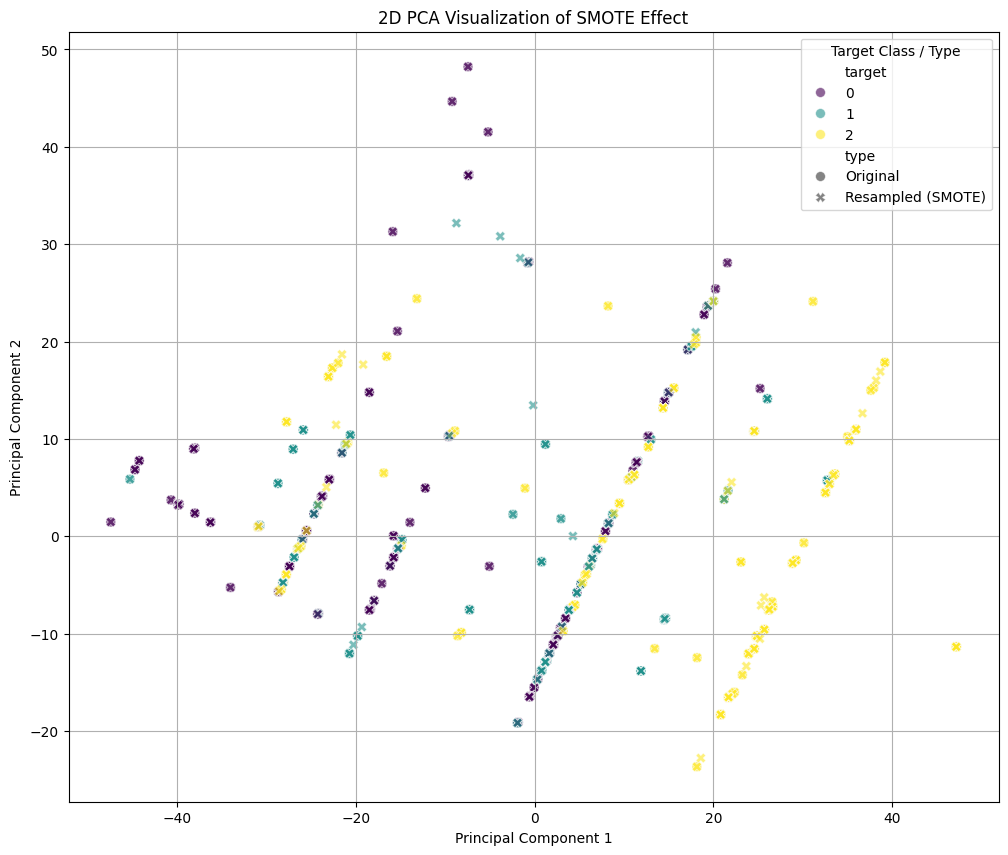

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
import pandas as pd
import numpy as np

# ---------------------------
# Step 27: Visualize SMOTE
# ---------------------------
print("\n=== Visualizing SMOTE ===")

# We need the original training data (X_train_filtered) and labels (y_train)
if 'X_train_filtered' not in locals() or 'y_train' not in locals():
    print("Training data (X_train_filtered, y_train) not found. Cannot visualize SMOTE.")
else:
    # Apply SMOTE to the training data
    # Note: SMOTE should be applied to the training data *before* any visualizations or model training on the augmented data if the goal is to see its direct effect.
    # Here, we apply it just for visualization purposes on the original features.
    smote = SMOTE(random_state=42)
    # SMOTE works best on numerical data, ensure X_train_filtered is suitable
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train_filtered, y_train)

    print(f"Original training data shape: {X_train_filtered.shape}")
    print(f"Resampled training data shape: {X_train_resampled.shape}")
    print(f"Original class distribution:\n{y_train.value_counts()}")
    print(f"Resampled class distribution:\n{y_train_resampled.value_counts()}")

    # Use PCA to reduce the original and resampled data to 2 dimensions for visualization
    pca_smote = PCA(n_components=2, random_state=42)
    X_pca_original = pca_smote.fit_transform(X_train_filtered)
    X_pca_resampled = pca_smote.transform(X_train_resampled) # Use the same PCA transformation

    # Create DataFrames for easier plotting
    pca_original_df = pd.DataFrame(data=X_pca_original, columns=['PCA1', 'PCA2'])
    pca_original_df['target'] = y_train.values
    pca_original_df['type'] = 'Original'

    pca_resampled_df = pd.DataFrame(data=X_pca_resampled, columns=['PCA1', 'PCA2'])
    pca_resampled_df['target'] = y_train_resampled.values
    pca_resampled_df['type'] = 'Resampled (SMOTE)'

    # Combine original and resampled data for plotting
    plot_df_smote = pd.concat([pca_original_df, pca_resampled_df], ignore_index=True)

    # Visualize the original and synthetic points in 2D PCA space
    plt.figure(figsize=(12, 10))
    # Use a color palette that distinguishes classes and points vs. synthetic points
    # Using 'type' for style and 'target' for hue
    sns.scatterplot(x='PCA1', y='PCA2', hue='target', style='type', data=plot_df_smote, palette='viridis', s=50, alpha=0.6)

    plt.title('2D PCA Visualization of SMOTE Effect')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.legend(title='Target Class / Type')
    plt.grid(True)
    plt.show()